# In this notebook we explore Earth's global average surface temperature, observed warming and its relation with greenhouse gases concentrations.

 __Author__: Sara Grisales-Vargas. For any questions regarding the contents of this notebook please contact sara.grisales.vargas@temple.edu

# *Datasets used in this notebook:*

## Greenhouse Gas Concentration Datasets

### 1. Monthly Atmospheric CO<sub>2</sub> Concentration Measurements from Mauna Loa Observatory, HI.
(*CO2_MaunaLoa_TimeSeries.csv*)
 *  Units: ppm (parts per million) of CO<sub>2</sub>
 *  March 1958 - March 2023

### 2. Globally Averaged Monthly Atmospheric CO<sub>2</sub> Concentration Measurements over Marine Surface Sites from NOAA’s Global Monitoring Laboratory 
(*CO2_NOAA_TimeSeries.csv*)
 *  Units: ppm of CO<sub>2</sub>
 *  January 1979 – January 2023

### 3. Globally Averaged Monthly Atmospheric CO<sub>2</sub> Concentration Measurements from the World data Centre for Greenhouse Gases (WDCGG) 
Operated by the Japan Meteorological Agency (JMA) under the Global Atmosphere Watch programme (GAW) of the World Meteorological Organization (WMO).
(*CO2_WDCGG_TimeSeries.csv*)
 *  Units: ppm of CO<sub>2</sub>
 *  January 1984 – December 2021

### 4. Globally Averaged Monthly Atmospheric CH<sub>4</sub> Concentration Measurements over Marine Surface Sites from NOAA’s Global Monitoring Laboratory
(*NOAA_CH4.csv*)
 *  Units: ppb (parts per billion) of CH<sub>4</sub>
 *  July 1983 – December 2022

### 5. Globally Averaged Monthly Atmospheric N<sub>2</sub>O Concentration Measurements from the World data Centre for Greenhouse Gases (WDCGG)
Operated by the Japan Meteorological Agency (JMA) under the Global Atmosphere Watch programme (GAW) of the World Meteorological Organization (WMO).
(*WDCGG_N2O.csv*)
 *  Units: ppb of N<sub>2</sub>O
 *  July 1983 – December 2021

> A mole fraction in dry air, micromol/mol, abbreviated as ppm (parts per million) 1 ppm indicates that one out of every million molecules in an air sample is  $ CO_2 $.
> 
> A mole fraction in dry air, abbreviated as ppb (parts per billion) 1 ppb 
indicates that one out of every billion molecules in an air sample i the gas of interest4

In [1]:
# import our packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd    
import cmocean 

%matplotlib inline                           
%config InlineBackend.figure_format='retina' 
plt.rcParams['figure.figsize'] = 12,6   

In [2]:
#Define home working directory
ees_climate_dir = 'C:/Users/TU_Climate24_Student/Desktop/ees_climate/'  #### This is the home directory we are always working out of

#Greenhouse gases datasets

co2_MaunaLoa = pd.read_csv(ees_climate_dir+'unit2_grisales/data/greenhouse_gases/CO2_MaunaLoa_TimeSeries.csv',parse_dates=['Date'])
co2_NOAA = pd.read_csv(ees_climate_dir+'unit2_grisales/data/greenhouse_gases/CO2_NOAA_TimeSeries.csv',parse_dates=['Date'])
co2_WDCGG = pd.read_csv(ees_climate_dir+'unit2_grisales/data/greenhouse_gases/CO2_WDCGG_TimeSeries.csv',parse_dates=['Date'])

#NO2 and CH4 observational datasets

ch4_NOAA = pd.read_csv(ees_climate_dir+'unit2_grisales/data/greenhouse_gases/NOAA_CH4.csv')
n2o_WDCGG = pd.read_csv(ees_climate_dir+'unit2_grisales/data/greenhouse_gases/WDCGG_N2O.csv')

#Convert Year and Month columns into a calendar date 
ch4_NOAA['Date'] = pd.to_datetime(ch4_NOAA[['Year', 'Month']].assign(day=1))
n2o_WDCGG['Date'] = pd.to_datetime(n2o_WDCGG[['Year', 'Month']].assign(day=1))

## Carbon Emission Datasets

### 1. Annual Carbon Emissions by Emission Type
(*Fossil_Fuel_Emission_By_Type.csv*)
 *  Units: MtC/yr (Megatons Carbon per year)
 *  1850 – 2021

### 2. Annual Territorial Fossil Fuel Emissions by Country / Region
(*Nation_Fossil_Fuel_Emissions.csv*)
 *  Units: MtC/yr (Megatons Carbon per year)
 *  1850 – 2021

In [3]:
#Carbon emission datasets

anual_C_emissions = pd.read_csv(ees_climate_dir+'unit2_grisales/data/greenhouse_gases/Fossil_Fuel_Emission_By_Type.csv')
ffemissions_country = pd.read_csv(ees_climate_dir+'unit2_grisales/data/greenhouse_gases/Nation_Fossil_Fuel_Emissions.csv')

## Global Average Surface Temperature Datasets

### Annual global mean surface air temperature datasets:
* Time Period: Varies, generally 1850 to present day.
* Units: Degrees Celsius

*gmt_Berkeley_Earth.csv*
*gmt_ERA5.csv*
*gmt_GISTEMP.csv*
*gmt_HadCRUT5.csv*
*gmt_JRA-55.csv*
*gmt_NOAAGlobalTemp.csv*

### Annual global mean surface air temperature over land:
* Time Period: Varies, generally 1850 to present day.
* Units: Degrees Celsius
  
lsat_Berkeley_Earth_Land.csv
lsat_CRUTEM5.csv

### Annual global mean surface temperature over the ocean (sea surface temperature):
* Time Period: Varies, generally 1850 to present day.
* Units: Degrees Celsius

sst_ERSSTv5.csv
sst_HadSST3.csv
sst_HadSST4.csv

In [4]:
#Surface temperature datasets

Berkeley_temp = pd.read_csv(ees_climate_dir+'unit2_grisales/data/temp/gmt_Berkeley_Earth.csv')
ERA5_temp = pd.read_csv(ees_climate_dir+'unit2_grisales/data/temp/gmt_ERA5.csv')
JRA_temp = pd.read_csv(ees_climate_dir+'unit2_grisales/data/temp/gmt_JRA-55.csv')
HadCRUT5_temp = pd.read_csv(ees_climate_dir+'unit2_grisales/data/temp/gmt_HadCRUT5.csv')
GISTEMP = pd.read_csv(ees_climate_dir+'unit2_grisales/data/temp/gmt_GISTEMP.csv')
NOAA_temp = pd.read_csv(ees_climate_dir+'unit2_grisales/data/temp/gmt_NOAAGlobalTemp.csv')

# Annual global mean surface air temperature over land

Berkeley_lsat = pd.read_csv(ees_climate_dir+'unit2_grisales/data/temp/lsat_Berkeley_Earth_Land.csv')
CRUTEM5_lsat = pd.read_csv(ees_climate_dir+'unit2_grisales/data/temp/lsat_CRUTEM5.csv')

#sea surface temperature

ERSST_sst = pd.read_csv(ees_climate_dir+'unit2_grisales/data/temp/sst_ERSSTv5.csv')
hadsst3_sst = pd.read_csv(ees_climate_dir+'unit2_grisales/data/temp/sst_HadSST3.csv')
hadsst4_sst = pd.read_csv(ees_climate_dir+'unit2_grisales/data/temp/sst_HadSST4.csv')

### <span style = "color: red">1</span>

The temperature of the Earth is determined by the balance between the amount of energy coming from the Sun (shortwave radiation), and the amount of energy reflected away from the Earth into space as heat (infrared or longwave radiation). If we analyze the energy balance assuming a planet without atmosphere, the Earth’s average temperature would be minus 18°C, However, thanks to the presence of greenhouse gases (GHG), the Earth’s average temperature is approximately 15°C. 

> ### So, how do GHG make the Earth 33°C warmer?

![image]( https://science.feedback.org/wp-content/uploads/2024/05/Screenshot-2024-05-13-at-14.08.29.png)

Source: https://science.feedback.org/how-co2-warms-earth-through-greenhouse-effect-why-co2-not-saturated-earth-atmosphere/

The natural greenhouse effect is a phenomenon caused by gases naturally present in the atmosphere that affect the behavior of longwave radiation. As the energy radiated by the Earth passes through the atmosphere, most of it is absorbed by certain gases, also known as greenhouse gases. These gases, which can be natural or anthropogenic, absorb and emit infrared radiation at specific wavelengths emitted by the Earth’s surface, these molecules do not absorb shortwave radiation. **Greenhouse gases (GHGs) emit infrared radiation in all directions, but the net amount emitted to space is normally less than would have been emitted in the absence of these absorbers** (IPCC, 2021). 

> ### GHGs keep the Earth’s average temperature approximately 33 °C warmer 


### <center> Atmospheric composition </center>
By volume, the dry air in Earth’s atmosphere is about 78.08 percent nitrogen, 20.95 percent oxygen, and 0.93 percent argon. A brew of trace gases accounts for the other approximately 0.04 percent, including the greenhouse gases carbon dioxide, methane, nitrous oxide, and ozone (Buis, 2019).

> Tiny solid or liquid particles known as aerosols, which are produced both naturally and by human activities, are also present in variable amounts (Builes, 2019).

![composition](https://science.nasa.gov/wp-content/uploads/2019/10/atmosphere-gas-proportions.svg.png?w=2048&format=webp)

Source: https://science.nasa.gov/earth/climate-change/greenhouse-gases/the-atmosphere-getting-a-handle-on-carbon-dioxide/

# <center> Key Greenhouse Gases </center>

#### Carbon dioxide (CO<sub>2</sub>) 

It is the primary greenhouse gas contributing to recent climate change. It is absorbed and emitted naturally as part of the carbon cycle, through plant and animal respiration, volcanic eruptions, and ocean-atmosphere exchange. Carbon dioxide enters the atmosphere through burning fossil fuels, solid waste, trees, and other biological materials, and as a result of certain chemical reactions, such as cement manufacturing (EPA, 2024).

> The carbon cycle is the process by which carbon continually moves from the atmosphere to the earth and then back to the atmosphere. On the earth, carbon is stored in rocks, sediments, the ocean, and in living organisms. Carbon is released back into the atmosphere when plants and animals die, as well as when fires burn, volcanoes erupt, and fossil fuels (such as coal, natural gas, and oil) are combusted. The carbon cycle ensures there is a balanced concentration of carbon in the different reservoirs on the planet. But a change in the amount of carbon in one reservoir affects all the others. Today, people are disturbing the carbon cycle by burning fossil fuels, which release large amounts of carbon dioxide into the atmosphere, and through land use changes that remove plants, which absorb carbon from the atmosphere (EPA, 2024).
> 
> ![image](https://www.worldatlas.com/r/w960-q80/upload/b6/4c/d1/carbon-cycle.png)
> Source: https://www.worldatlas.com/articles/what-is-the-carbon-cycle.html#:~:text=The%20Carbon%20Cycle%20moves%20in,moves%20within%20the%20carbon%20cycle.

#### Methane (CH<sub>4</sub>)
Both natural and human activities produce methane. For example, natural wetlands, agricultural activities, and fossil fuel extraction and transport all emit methane (EPA, 2024).

#### Nitrous Oxide (N<sub>2</sub>O)
Nitrous oxide is produced mainly through agricultural activities and natural biological processes. Fossil fuel burning and industrial processes also create nitrous oxide (EPA, 2024).

#### F-Gases
Chlorofluorocarbons, hydrochlorofluorocarbons, hydrofluorocarbons, perfluorocarbons, and sulfur hexafluoride, together called F-gases, are often used in coolants, foaming agents, fire extinguishers, solvents, pesticides, and aerosol propellants (EPA, 2024).

#### Ground-Level Ozone
Ground-level ozone is created by a chemical reaction between emissions of nitrogen oxides and volatile organic compounds from automobiles, power plants, and other industrial and commercial sources in the presence of sunlight. In addition to trapping heat, in the troposphere ozone is a pollutant that can cause respiratory health problems and damage crops and ecosystems (EPA, 2024).

#### Water Vapor
Water vapor is another greenhouse gas and plays a key role in climate feedbacks because of its heat-trapping ability. Water vapor concentration varies significantly depending on temperature, where warmer air holds more moisture than cooler air. Therefore, as greenhouse gas concentrations increase and global temperatures rise, the total amount of water vapor in the atmosphere also increases, further amplifying the warming effect (EPA, 2024).


> Further readings on The Greenhouse Effect be found in:
> * [Climate Change 2021 – The Physical Science Basis. Contribution of Working Group I to the Sixth Assessment Report of the Intergovernmental Panel on Climate Change](https://doi.org/10.1017/9781009157896)
> * [How CO2 warms Earth through the greenhouse effect and why CO2 is not ‘saturated’ in Earth’s atmosphere](https://science.feedback.org/how-co2-warms-earth-through-greenhouse-effect-why-co2-not-saturated-earth-atmosphere/).


### <span style = "color: red">2 & 3</span>

So far, we have seen that GHG are a natural compound of Earth’s atmosphere, however, since the beginning of the Industrial Revolution (1760), growing concentrations of greenhouse gases in the atmosphere from human activities are increasing the magnitude of the greenhouse effect; sometimes called **the enhanced greenhouse effect**. The change in GHG concentrations due to anthropogenic emissions contributes to an instantaneous radiative forcing, where Earth’s surface temperature and troposphere warm in response to this forcing (IPCC, 2021).

![image](https://science.feedback.org/wp-content/uploads/2024/05/fig2_may-scaled.jpeg)

Source: https://science.feedback.org/how-co2-warms-earth-through-greenhouse-effect-why-co2-not-saturated-earth-atmosphere/

In [5]:
#CO2 dataset
co2_WDCGG

,Date,WDCGG CO2 (ppm),WDCGG CO2 uncertainty
0,1984-01-01,345.27,NaN
1,1984-02-01,345.69,NaN
2,1984-03-01,345.89,NaN
3,1984-04-01,345.95,NaN
4,1984-05-01,345.47,NaN
...,...,...,...
451,2021-08-01,412.79,NaN
452,2021-09-01,413.48,NaN
453,2021-10-01,415.16,NaN
454,2021-11-01,416.83,NaN


In [6]:
co2_WDCGG.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456 entries, 0 to 455
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   456 non-null    datetime64[ns]
 1   WDCGG CO2 (ppm)        456 non-null    float64       
 2   WDCGG CO2 uncertainty  0 non-null      float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 10.8 KB


In [5]:
#Filter the database for the last full year of monthly data of the greenghouses datasets
co2_2021 = co2_WDCGG.loc[(co2_WDCGG['Date'] >= '2021-01')& (co2_WDCGG['Date'] < '2021-12')]
co2_2021

,Date,WDCGG CO2 (ppm),WDCGG CO2 uncertainty
444,2021-01-01,416.06,NaN
445,2021-02-01,416.54,NaN
446,2021-03-01,416.86,NaN
447,2021-04-01,416.94,NaN
448,2021-05-01,416.65,NaN
449,2021-06-01,415.48,NaN
450,2021-07-01,413.83,NaN
451,2021-08-01,412.79,NaN
452,2021-09-01,413.48,NaN
453,2021-10-01,415.16,NaN


In [16]:
ch4_NOAA

,Year,Month,NOAA CH4 (ppb),NOAA CH4 uncertainty,Date
0,1983,7,1625.95,4.116,1983-07-01
1,1983,8,1628.06,5.272,1983-08-01
2,1983,9,1638.44,4.567,1983-09-01
3,1983,10,1644.80,3.116,1983-10-01
4,1983,11,1642.60,1.529,1983-11-01
...,...,...,...,...,...
469,2022,8,1908.78,NaN,2022-08-01
470,2022,9,1915.53,NaN,2022-09-01
471,2022,10,1920.01,NaN,2022-10-01
472,2022,11,1923.78,NaN,2022-11-01


In [6]:
ch4_2021 = ch4_NOAA.loc[(ch4_NOAA['Date'] >= '2021-01')& (ch4_NOAA['Date'] < '2021-12')]
ch4_2021

,Year,Month,NOAA CH4 (ppb),NOAA CH4 uncertainty,Date
450,2021,1,1889.54,2.666,2021-01-01
451,2021,2,1887.57,2.058,2021-02-01
452,2021,3,1888.74,1.823,2021-03-01
453,2021,4,1891.22,1.117,2021-04-01
454,2021,5,1891.60,1.372,2021-05-01
455,2021,6,1888.47,1.529,2021-06-01
456,2021,7,1886.36,1.529,2021-07-01
457,2021,8,1892.60,2.352,2021-08-01
458,2021,9,1902.65,2.411,2021-09-01
459,2021,10,1907.99,1.588,2021-10-01


In [15]:
n2o_WDCGG

,Year,Month,WDCGG N2O (ppb),WDCGG N2O uncertainty,Date
0,1984,1,303.8,NaN,1984-01-01
1,1984,2,303.8,NaN,1984-02-01
2,1984,3,303.7,NaN,1984-03-01
3,1984,4,303.7,NaN,1984-04-01
4,1984,5,303.7,NaN,1984-05-01
...,...,...,...,...,...
451,2021,8,334.5,NaN,2021-08-01
452,2021,9,334.7,NaN,2021-09-01
453,2021,10,334.9,NaN,2021-10-01
454,2021,11,335.1,NaN,2021-11-01


In [7]:
n2o_2021 = n2o_WDCGG.loc[(n2o_WDCGG['Date'] >= '2021-01')& (n2o_WDCGG['Date'] < '2021-12')]
n2o_2021

,Year,Month,WDCGG N2O (ppb),WDCGG N2O uncertainty,Date
444,2021,1,334.1,NaN,2021-01-01
445,2021,2,334.2,NaN,2021-02-01
446,2021,3,334.2,NaN,2021-03-01
447,2021,4,334.2,NaN,2021-04-01
448,2021,5,334.2,NaN,2021-05-01
449,2021,6,334.3,NaN,2021-06-01
450,2021,7,334.4,NaN,2021-07-01
451,2021,8,334.5,NaN,2021-08-01
452,2021,9,334.7,NaN,2021-09-01
453,2021,10,334.9,NaN,2021-10-01


In [8]:
#Average of CO2 data for 2021
ave_co2_2021 = co2_2021['WDCGG CO2 (ppm)'].mean()
ave_ch4_2021 = ch4_2021['NOAA CH4 (ppb)'].mean()
ave_n2o_2021 = n2o_2021['WDCGG N2O (ppb)'].mean()

print('CO2',round(ave_co2_2021,2),'ppm')
print('CH4',round(ave_ch4_2021,2),'ppb')
print('N2O',round(ave_n2o_2021,2),'ppb')

CO2 415.51 ppm
CH4 1894.21 ppb
N2O 334.44 ppb


In [9]:
#Define pre-industrial levels of each GHG
pre_co2 = 280
pre_ch4 = 700
pre_n2o = 280

#Calculate the percentage change of each GHG relative to the preindustrial levels
pc_co2 = (ave_co2_2021 - pre_co2)/pre_co2 * 100
pc_ch4 = (ave_ch4_2021 - pre_ch4)/pre_ch4 * 100
pc_n2o = (ave_n2o_2021 - pre_n2o)/pre_n2o * 100

print('CO2',round(pc_co2,2),'%')
print('CH4',round(pc_ch4,2),'%')
print('N2O',round(pc_n2o,2),'%')

CO2 48.4 %
CH4 170.6 %
N2O 19.44 %


Pre-industrial atmospheric CO₂ levels (before 1760) were around 280 parts per million (ppm). However, as of December 2021, current levels have risen to 415.5 ppm, reflecting a 48% increase. While this significant rise is observed in several key greenhouse gases (GHGs), the most dramatic change over centuries of human activity is associated with methane (CH₄), which has increased by over 170% compared to its pre-industrial concentrations (Table 1). 

<center> Table 1. Pre-industrial and current concentrations of greenhouse gases </center>

| GHG |	Pre-industrial concentrations | 2021 concentrations | Percentage change (%) |
| --- | --- | --- | --- |
| CO<sub>2</sub> | 280 ppm | 415.51 ppm | 48.4 |
| CH<sub>4</sub> | 700 ppb | 1894.21 ppb | 170.6 |
| N<sub>2</sub>O | 280 ppb | 334.44 ppb | 19.44 |


Methane has both anthropogenic and natural sources, with over 60% of methane emissions coming from human activities. Agriculture is the largest human source, contributing 40% of these emissions, primarily from livestock rearing, animal manure, and rice production. This is followed by 35% from natural gas and oil production, distribution systems, and coal mines. Additionally, 20% of methane emissions come from waste management, including landfills and wastewater treatment (UNEP & CCAC, 2021).


### <span style = "color: red">4</span>

So far, we have introduce the basics of GHGs and how they warm the Earth by absorbing energy and slowing the rate at which the energy escapes to space. However, different GHGs can have different effects on the Earth's warming. When discussing how these gases differ from each other in terms of their impact on climate change, two key factors are often highlighted: potency (in terms of the Global Warming Potential) and how long they stay in the atmosphere (residence time or atmospheric lifetime) (EPA, 2024b).

Starting in 1990, the Intergovernmental Panel on Climate Change (IPCC) used the Global Warming Potential (GWP) to allow comparisons of the global warming impacts of different gases. The GWP is a measure of how much energy the emission of 1 ton of a gas will absorb over a given period of time, relative to the emission of 1 ton of carbon dioxide (CO<sub>2</sub>). The larger the GWP, the more that a given gas warms the Earth compared to CO<sub>2</sub> over that time period (Table 2). The time period usually used for GWPs is 100 years (EPA, 2024b).

<center> Table 2. Global warming potentials and atmospheric residence for key GHG (EPA, 2024b). </center>

| GHG |	GWP over 100 years | Residence (years) |
| --- | --- | --- |
| CO<sub>2</sub>| 1 | 100 |
| CH<sub>4</sub> | 27-30 | 10 |
| N<sub>2</sub>O | 273 | >100 |


### <span style = "color: red">5</span>

The GWPs provide a common unit of measure, which allows analysts to add up emissions estimates of different gases to compile a national or global GHG inventory in order to identify the main sources of emission, and allows policymakers to compare emissions reduction opportunities across sectors and gases (EPA, 2024b), because: 

> ### GHGs emissions come from many sectors!

![Image](https://www.epa.gov/system/files/styles/large/private/images/2023-08/Fig-2-Global-GHG-Emissions-by-Sector.png?itok=hjyHDjpZ)

Source: https://www.epa.gov/ghgemissions/global-greenhouse-gas-overview


In general, greenhouse gases come from a variety of human activities, including burning fossil fuels for heat and energy, deforestation, fertilizing crops, storing waste in landfills, raising livestock, and producing some industrial products. In 2019, the largest individual subsector contributing to global GHG emissions was electricity and heat generation at 14 GtCO2-eq GHGs emissions by sector were related to the following activities (Dhakal et al., 2022):
* **<span style = "color: blue">Electricity and Heat Production (34% of 2019 global greenhouse gas emissions):** </span>  The burning of coal, natural gas, and oil for electricity and heat is the largest single source of global greenhouse gas emissions.
  
*	**<span style = "color: green">Industry (24% of 2019 global greenhouse gas emissions):** </span> Greenhouse gas emissions from industry primarily involve fossil fuels burned on site at facilities for energy. This sector also includes emissions from chemical, metallurgical, and mineral transformation processes not associated with energy consumption and emissions from waste management activities.
  
*	**<span style = "color: orange">Agriculture, Forestry, and Other Land Use (22% of 2019 global greenhouse gas emissions):** </span> Greenhouse gas emissions from this sector come mostly from agriculture (cultivation of crops and livestock) and deforestation.
  
*	**<span style = "color: darkgrey">Transportation (15% of 2019 global greenhouse gas emissions):** </span> Greenhouse gas emissions from this sector primarily involve fossil fuels burned for road, rail, air, and marine transportation. Almost all (95%) of the world's transportation energy comes from petroleum-based fuels, largely gasoline and diesel.
  
*	**<span style = "color: red">Buildings (6% of 2019 global greenhouse gas emissions):** </span> Greenhouse gas emissions from this sector arise from onsite energy generation and burning fuels for heat in buildings or cooking in homes.

<center> Table 3. Anthropogenic sources of emissions of GHG. </center>

| GHG |	Emission sources | Activities |
| --- | --- | ---  |
| **CO<sub>2</sub>** | Transportation, Electricity, Industry, Land Use, Land-Use Change, and Forestry (LULUCF) | ![CO2_Budget](https://globalcarbonatlas.org/www-site/uploads/2023/12/carbonBudget_2022.png) |
| **CH<sub>4</sub>** | Agriculture, LULUCF, Energy and Forestry, Waste | ![CH4_budget](https://www.globalcarbonproject.org/methanebudget/archive/2020/MethaneInfographic2020.png) |
| **N<sub>2</sub>O** | Agriculture Soil Management, Fuel Combustion, Industry, Waste | ![N2O_budget](https://globalcarbonatlas.org/www-site/uploads/2024/06/Global_N2O_Budget2024_simpleFigure_FINAL-1.png) |

Sources: 
* [Global Carbon budget 2023](https://globalcarbonatlas.org/budgets/carbon-budget/)
* [Global Methane Budget 2008-2019](https://www.globalcarbonproject.org/methanebudget/archive.htm)
* [Global N2O budget 2010-2019](https://globalcarbonatlas.org/budgets/436-2/)


### <span style = "color: red">6</span>

So far, we have established that greenhouse gases play a critical role in maintaining Earth’s climate by trapping longwave radiation. However, to fully understand the current trends in CO₂ levels, it is essential to look at how concentrations have changed over time. CO₂ levels have naturally fluctuated between glacial and interglacial periods (warm episodes that began with a small increase in incoming sunlight and variations of Earth’s orbital patterns, called Milankovitch cycles). As the oceans warmed, they outgassed carbon dioxide, amplifying the initial, solar-driven warming (Lindsey, 2024).

> Based on ice core analysis, which analyzes the gas composition in air bubbles trapped in thick layers of ice accumulated for hundreds of thousands of years. These bubbles contain samples of the atmosphere from the time when the snow fell, providing a direct archive of past atmospheric composition. Each layer of ice represents a specific time period, so by drilling deeper into the ice sheet, scientists can extract layers that are thousands or even hundreds of thousands of years old. The deeper the layer, the older the trapped air (Lindsey, 2024).
>
> ![image]( https://www.climate.gov/sites/default/files/styles/full_width_620_alternate_image/public/2021-10/denali_core_610.jpg?itok=2FfMUvF8)
>
> Source: https://www.climate.gov/sites/default/files/styles/full_width_620_alternate_image/public/2021-10/denali_core_610.jpg?itok=2FfMUvF8

CO₂ concentrations over the past 800,000 years, derived from ice-core data. The fluctuations correspond to ice ages (lower CO₂) and warmer interglacial periods (higher CO₂). During this entire period, CO₂ levels never exceeded 300 ppm. However, the rise over the last 60 years has occurred at a rate 100 times faster than any natural increase in the past. On a geological timescale, the rapid rise from the end of the last ice age to today, appears almost instantaneous (Lindsey, 2024).

![CO2paleoclimate]( https://www.climate.gov/sites/default/files/2024-04/ClimateDashboard-atmospheric-carbon-dioxide-image-paleo-20240405-1400px.png)
Source: Rebecca Lindsey (2024). Climate Change: Atmospheric Carbon Dioxide. https://www.climate.gov/news-features/understanding-climate/climate-change-atmospheric-carbon-dioxide
).


### <span style = "color: red">7</span>

Since the Industrial Revolution, human activities have caused an unprecedented increase in GHG levels, which now exceed the natural range seen in these past cycles, as seen in the concentration trends of three major GHG from 1984 to 2021 (Figure 1), based on data from global atmospheric observation networks. All GHG show a steady upward trend over the observed period, with CO₂ levels showing seasonal oscillations. N<sub>2</sub>O concentrations have increased more gradually but steadily, with no visible seasonal cycles, reflecting the more stable nature of N<sub>2</sub>O sources (Table 3). 

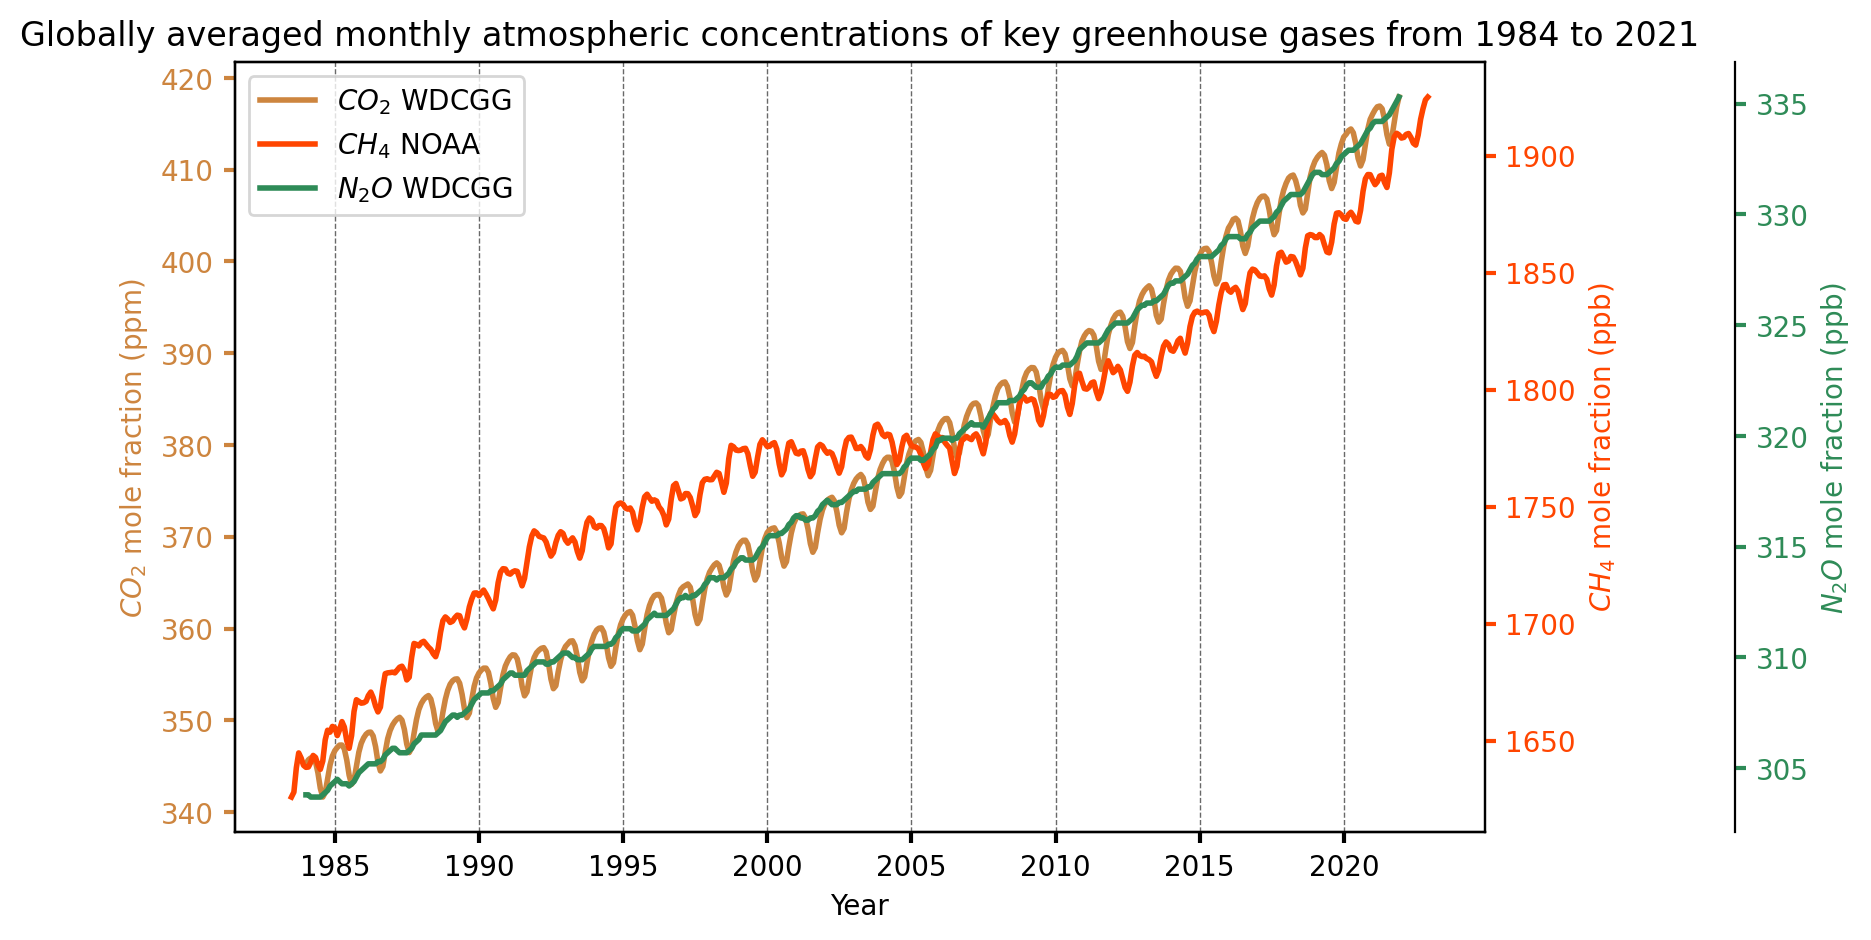

In [31]:
#Source for the code: https://matplotlib.org/3.4.3/gallery/ticks_and_spines/multiple_yaxis_with_spines.html

fig, ax = plt.subplots(figsize = (10, 5))
fig.subplots_adjust(right=0.75)

#Create twin axes
twin1 = ax.twinx()
twin2 = ax.twinx()

# Offset the right spine of twin2.  The ticks and label have already been
# placed on the right by twinx above.
twin2.spines.right.set_position(("axes", 1.2))

#First plot
p1, = ax.plot(co2_WDCGG['Date'],
        co2_WDCGG['WDCGG CO2 (ppm)'],
        linewidth=2,label=r'$ CO_2 $ WDCGG',
        color='Peru')
# Second plot
p2, = twin1.plot(ch4_NOAA['Date'],
        ch4_NOAA['NOAA CH4 (ppb)'],
        linewidth=2,label=r'$ CH_4$ NOAA',
        color='orangered')
#Third plot
p3, = twin2.plot(n2o_WDCGG['Date'],
        n2o_WDCGG['WDCGG N2O (ppb)'],
        linewidth=2,label=r'$ N_2O$ WDCGG',
        color='seagreen')


## plot a legend on the ax
ax.legend(handles=[p1, p2, p3]) 

## add plot title:
ax.set_title('Globally averaged monthly atmospheric concentrations of key greenhouse gases from 1984 to 2021')

## add axes labes:
ax.set_ylabel(r'$ CO_2 $ mole fraction (ppm)')
ax.set_xlabel('Year')
#Add labels to additional axes
twin1.set_ylabel(r'$ CH_4$ mole fraction (ppb)')
twin2.set_ylabel(r'$ N_2O$ mole fraction (ppb)')

#Add vertical grid 
ax.grid(True,axis='x',linestyle='--', linewidth=0.5, color = 'dimgray')

#Add the same color of each plot to the axis labels
ax.yaxis.label.set_color(p1.get_color())
twin1.yaxis.label.set_color(p2.get_color())
twin2.yaxis.label.set_color(p3.get_color())

#Add the same color of each plot to the axis ticks and numbers
tkw = dict(size=4, width=1.5)
ax.tick_params(axis='y', colors=p1.get_color(), **tkw)
twin1.tick_params(axis='y', colors=p2.get_color(), **tkw)
twin2.tick_params(axis='y', colors=p3.get_color(), **tkw)
ax.tick_params(axis='x', **tkw)

**Figure 1.** Globally averaged monthly atmospheric concentrations of key greenhouse gases from 1984 to 2021. CO₂ (brown line) and N₂O (green line) measurements from the World data Centre for Greenhouse Gases (WDCGG) operated by the Japan Meteorological Agency (JMA) under the Global Atmosphere Watch programme (GAW) of the World Meteorological Organization (WMO) and CH<sub>4</sub> (red line) measurements over Marine Surface Sites from NOAA’s Global Monitoring Laboratory.



On the other hand, CH<sub>4</sub> levels differed from the upward trend showed by the other GHGs. After rising for nearly two decades, global methane levels increment abruptly stopped from 1999 to 2006 (this period was known as **the methane plateau**) and began to grow again in 2007 (Figure 2). The 7-year plateau and renewed growth since have been the subject of conflicting explanations in the literature, partly because of how many different processes produce the gas and partly because the removal processes are difficult to measure. However, while no single factor can fully explain the lack of increase during this period, several potential reasons have been identified, with the reduction in fossil fuel emissions having a greater impact (Sustainable Gas Institute, 2023; Saunois, 2017):

* Decreased microbial methane production
* A more active methane sink: hydroxyl (OH) methane sink has increased, which has offset the increase in methane emissions.
* A reduction in biomass burning
* A reduction of fossil fuel emissions from oil and gas production and investment into updating oil and gas infrastructure (largely a result of the collapse of the Soviet Union in 1992).
* The reduction in natural gas venting and flaring in oil fields contributed to this decrease, rather than a reduction in biofuel usage or biomass burning.


Text(1999-04-01 00:00:00, 1810, 'The methane\nplateau')

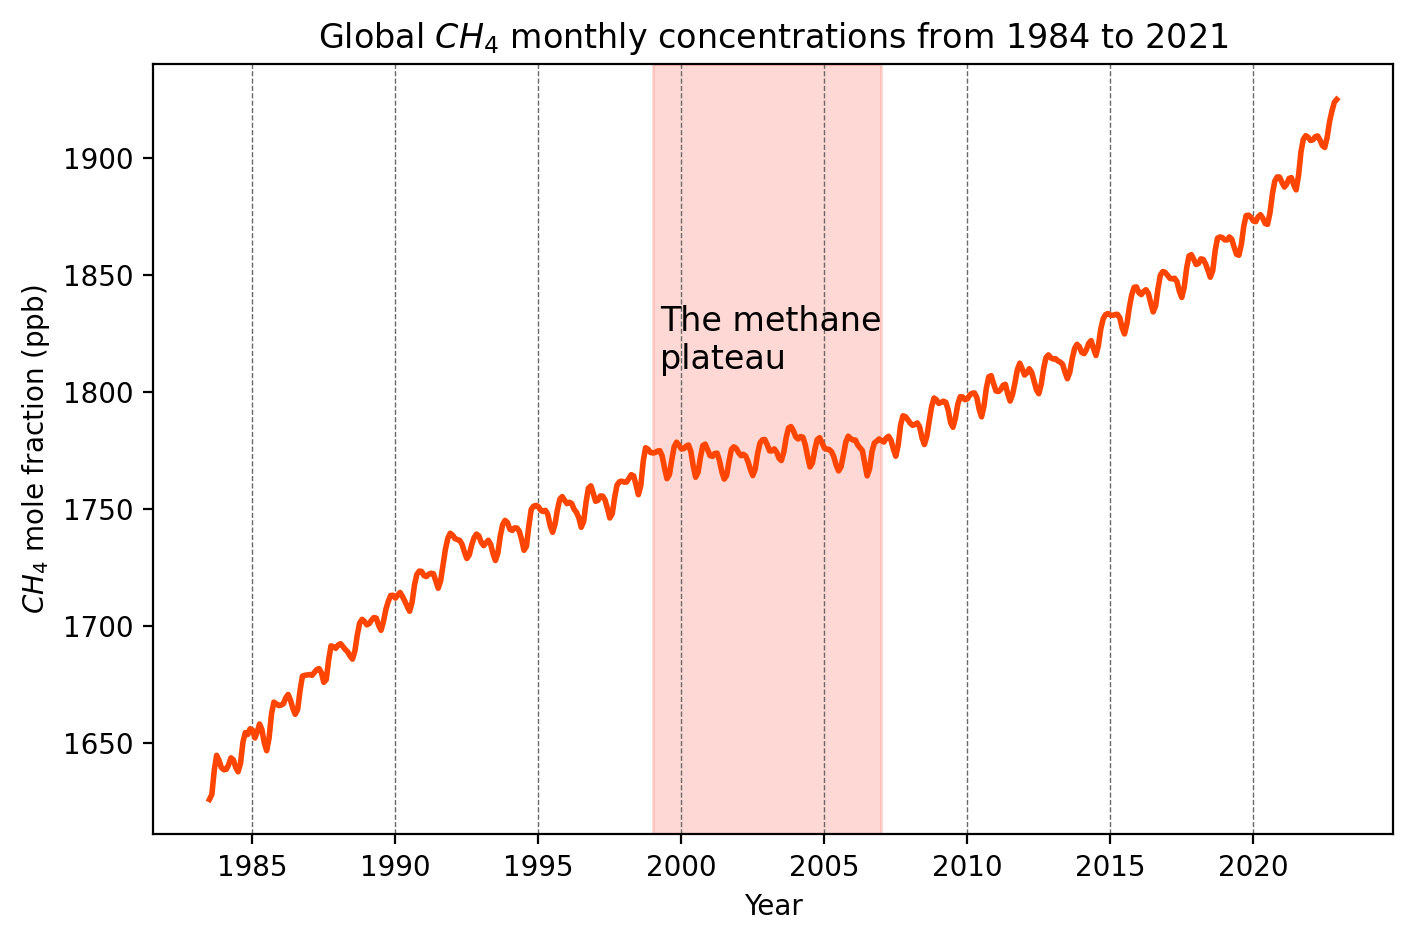

In [10]:
fig, ax = plt.subplots(figsize = (8, 5))

# Second plot
ax.plot(ch4_NOAA['Date'],
        ch4_NOAA['NOAA CH4 (ppb)'],
        linewidth=2,label=r'$ CH_4$ NOAA',
        color='orangered')

## add plot title:
ax.set_title(r'Global $ CH_4$ monthly concentrations from 1984 to 2021')

## add axes labes:
ax.set_ylabel(r'$ CH_4$ mole fraction (ppb)')
ax.set_xlabel('Year')

#Add vertical grid 
ax.grid(True,axis='x',linestyle='--', linewidth=0.5, color = 'dimgray')

#Add rectangle to highlight the methane tableau (1999 to 2006)
ax.axvspan('1999-01-01', '2006-12-31',  alpha=0.3, color='salmon',label='1999-2006')

# Add the text starting at x=1999-04-01
ax.text(pd.to_datetime('1999-04-01'), 1810, 'The methane\nplateau', fontsize=12, color='black')

#ax.legend()

**Figure 2.** Globally averaged monthly methane concentrations measurements over Marine Surface Sites from NOAA’s Global Monitoring Laboratory from 1984 to 2021. The shaded area highlights the methane plateau observed between 1999 and 2006, where CH₄ concentrations showed minimal increase.

### <span style = "color: red">8</span>

So far, we have become familiar with the global trend of rising CO<sub>2</sub> concentrations, which is steadily increasing over time. But if we zoom in a little closer and look at the monthly data, a fascinating seasonal cycle emerges, and that is what this graph from the Mauna Loa Observatory reveals over the past three years (Figure 3). There is a consistent pattern each year: CO<sub>2</sub> levels peak around May and drop to their lowest around September. The short-term (seasonal) variations in CO₂ levels are primarily driven by the natural processes of photosynthesis and respiration in plants. During the spring and summer months, plants in the Northern Hemisphere absorb CO₂ from the atmosphere for photosynthesis, which causes a decrease in atmospheric CO₂ levels. As fall and winter arrive, photosynthesis slows down and plants, along with other organisms, release CO₂ back into the atmosphere through respiration and decomposition, leading to an increase in CO₂ levels (Tans & Thoning, 2020; Keeling & Whorf, 2004).

In [10]:
co2_ML_2021 = co2_MaunaLoa.loc[(co2_MaunaLoa['Date'] >= '2021-01')& (co2_MaunaLoa['Date'] <= '2021-12')]
# Extract the month from the 'Date' column
co2_ML_2021['Month'] = co2_ML_2021['Date'].dt.month
co2_ML_2021

C:\Users\TU_Climate24_Student\AppData\Local\Temp\ipykernel_5312\1227288669.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  co2_ML_2021['Month'] = co2_ML_2021['Date'].dt.month


,Date,Mauna Loa CO2 (ppm),Mauna Loa CO2 uncertainty,Month
754,2021-01-01,415.52,NaN,1
755,2021-02-01,416.75,NaN,2
756,2021-03-01,417.64,NaN,3
757,2021-04-01,419.05,NaN,4
758,2021-05-01,419.13,NaN,5
759,2021-06-01,418.94,NaN,6
760,2021-07-01,416.96,NaN,7
761,2021-08-01,414.47,NaN,8
762,2021-09-01,413.30,NaN,9
763,2021-10-01,413.93,NaN,10


In [11]:
#Filter the database for the last full year of monthly data of the greenghouses datasets
co2_ML_2020 = co2_MaunaLoa.loc[(co2_MaunaLoa['Date'] >= '2020-01')& (co2_MaunaLoa['Date'] <= '2020-12')]
co2_ML_2019 = co2_MaunaLoa.loc[(co2_MaunaLoa['Date'] >= '2019-01')& (co2_MaunaLoa['Date'] <= '2019-12')]

# Extract the month from the 'Date' column
co2_ML_2020['Month'] = co2_ML_2020['Date'].dt.month
co2_ML_2019['Month'] = co2_ML_2019['Date'].dt.month

C:\Users\TU_Climate24_Student\AppData\Local\Temp\ipykernel_5312\2955429138.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  co2_ML_2020['Month'] = co2_ML_2020['Date'].dt.month
C:\Users\TU_Climate24_Student\AppData\Local\Temp\ipykernel_5312\2955429138.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  co2_ML_2019['Month'] = co2_ML_2019['Date'].dt.month


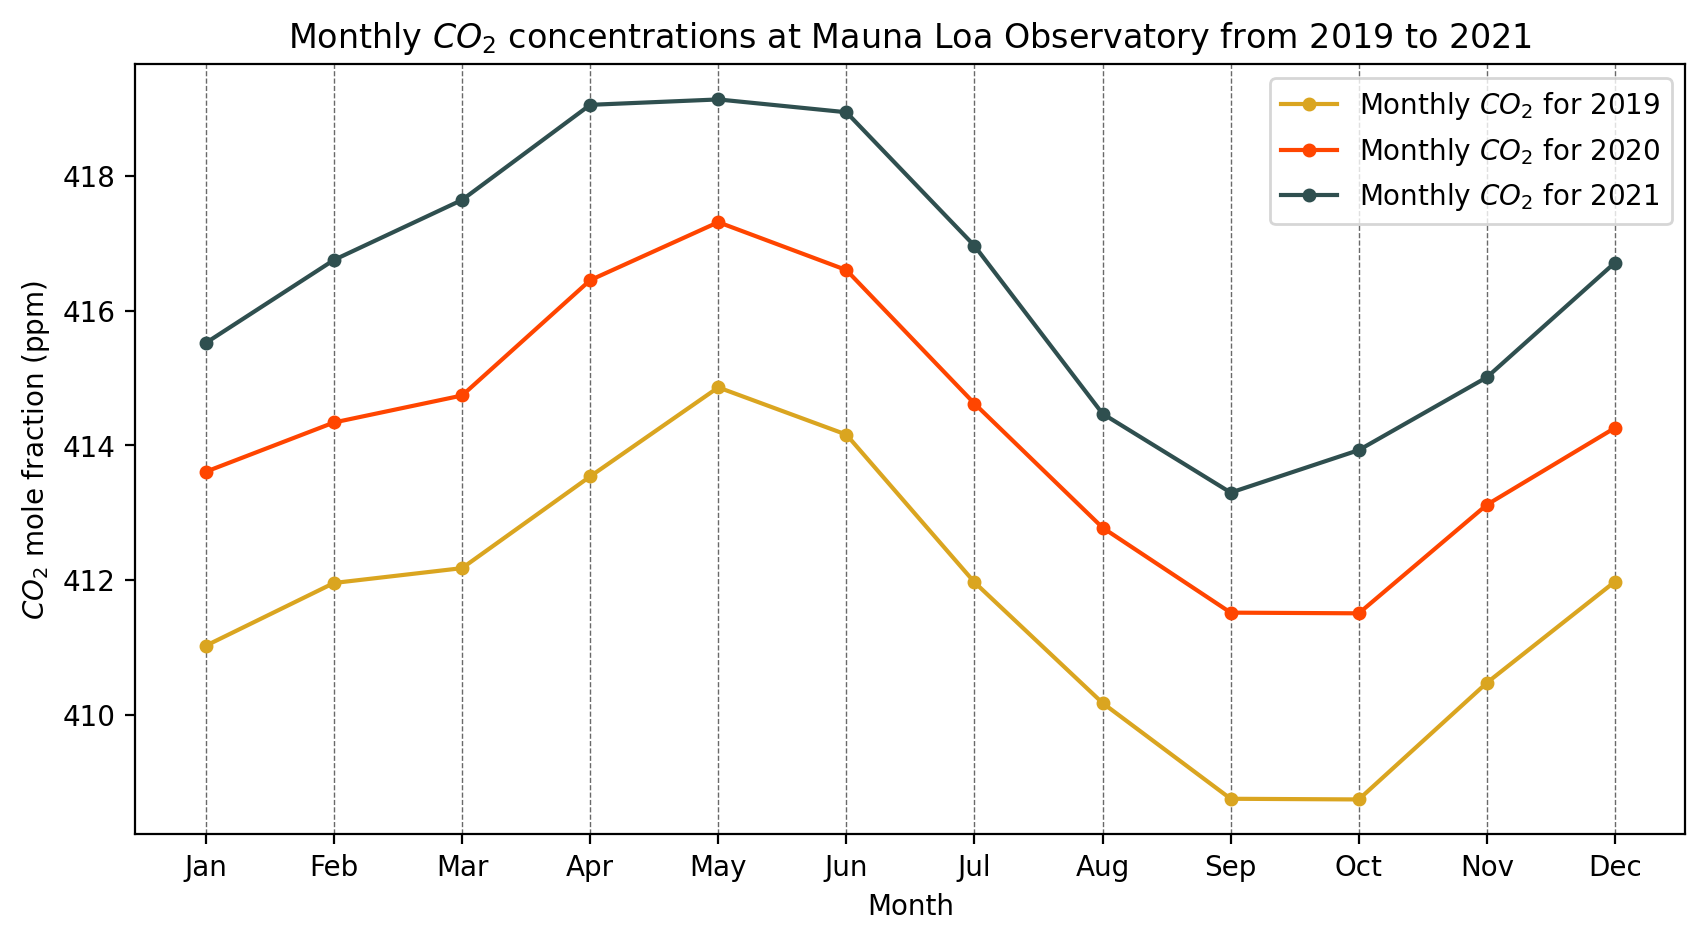

In [12]:
# Create a plot for 2019, 2020 and 2021
fig, ax = plt.subplots(figsize = (10, 5))

# Plot the data
ax.plot(co2_ML_2019['Month'], co2_ML_2019['Mauna Loa CO2 (ppm)'], label=r'Monthly $ CO_2 $ for 2019',
        marker='o', markersize = 4,color='goldenrod')
ax.plot(co2_ML_2020['Month'], co2_ML_2020['Mauna Loa CO2 (ppm)'], label=r'Monthly $ CO_2 $ for 2020',
        marker='o', markersize = 4,color='orangered')
ax.plot(co2_ML_2021['Month'], co2_ML_2021['Mauna Loa CO2 (ppm)'], label=r'Monthly $ CO_2 $ for 2021',
        marker='o', markersize = 4,color='darkslategrey')

# Customize the x-axis to show months only
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Add labels and legend
ax.set_xlabel('Month')
ax.set_ylabel(r'$ CO_2 $ mole fraction (ppm)')
ax.legend()

## add plot title:
ax.set_title(r'Monthly $ CO_2 $ concentrations at Mauna Loa Observatory from 2019 to 2021')

#Add vertical grid 
ax.grid(True,axis='x',linestyle='--', linewidth=0.5, color = 'dimgray')

#Save image in working directory
#fig.savefig('CO2_ML_2019-2021.png')

**Figure 3.** Monthly CO<sub>2</sub> atmospheric concentration measurements at Mauna Loa Observatory, HI for 2019 (yellow line), 2020 (red line) and 2021 (gray line).

This cyclic pattern of CO₂ concentrations is more pronounced in the Northern Hemisphere due to the larger land area and greater presence of vegetation compared to the Southern Hemisphere, where ocean dominates, and seasonal variations are much smaller. Additionally, because atmospheric mixing between the hemispheres is slow, seasonal CO₂ fluctuations are more confined to the hemisphere where they occur (Keeling & Whorf, 2004). Sites in the Northern Hemisphere, like Mauna Loa, experience stronger seasonal fluctuations, while sites closer to the equator and in the Southern Hemisphere, show much smaller or negligible seasonal changes. This difference reflects the varying levels of photosynthetic activity and land-to-ocean ratios between the hemispheres (Keeling & Whorf, 2004).

### <span style = "color: red">9</span>

Despite the CO<sub>2</sub> natural seasonal fluctuations, the overall trend is upward. This rise is a direct indicator of the ongoing buildup of greenhouse gases, contributing to global climate change. But these CO<sub>2</sub> and overall GHG contributions depend on the region.

### According to data from the World Resources Institute, the **top GHG emitting countries** include:

## China, United States, India, European Union, Russia, Japan, Brazil, Indonesia, Iran, and Canada

Together, these countries represent a significant portion of global emissions. The world’s top three emitters (China, the United States, and India) alone account for 42.6% of total global GHG emissions, which is 15 times more than the combined emissions of the bottom 100 countries, which contribute only 2.9%. 

**Electricity and heat production** is the largest contributor to GHG emissions in many of the top-emitting countries for 2019 (Table 3). China (44.2%), India (36.7%), Japan (46.7%), and Russia (35.2%) all have a significant portion of their total emissions coming from this sector, indicating their reliance on fossil fuels for energy generation. The European Union shows a split between electricity and heat (29.3%) and transportation (24.7%), reflecting the importance of both sectors in its overall emissions inventory (Friedrich, Ge, Pickens & Vigna, 2023). 

> In the United States, **electricity and heat production** accounts for 32.8% of total emissions, but **transportation** is nearly as significant, contributing 30.3%. The third-largest economic sector in terms of emissions is **building**, which accounted for 9.3% of total emissions in 2019 (Friedrich, Ge, Pickens & Vigna, 2023).

On the other hand, Brazil stands out, with nearly half (47.7%) of its emissions coming from agriculture. In Iran, fugitive emissions from the oil and gas sector account for a significant share (21.2%) of its total emissions. This distribution highlights the different economic activities driving emissions in each country and suggests that sector-specific policies will be crucial in addressing GHG reductions globally (Friedrich, Ge, Pickens & Vigna, 2023).


<center> Table 3. Percentage of total emissions  by economic sector for the top GHG emitting countries (Friedrich, Ge, Pickens & Vigna, 2023).</center>

| Country |	Economic sector | Percentage of total emissions |
| --- | --- | --- |
| China	| Electricity and Heat | 44.2 |
| United States | Electricity and Heat | 32.8 |
| United States | Transportation | 30.3 |
| United States | Building | 9.3 |
| India	| Electricity and Heat | 36.7 |
| European Union | Electricity and Heat	| 29.3 |
| European Union |	Transportation	|	24.7 |
| Russia | Electricity and Heat	|	35.2 |
|Japan | Electricity and Heat	|	46.7 |
| Brazil | Agriculture	| 47.7 |
| Indonesia | Electricity and Heat	| 25.8 |
| Iran | Electricity and Heat	| 22.7 |
| Iran | Fugitive Emissions	| 21.2 |
| Canada | Electricity and Heat |	28.8 |
|Canada | Transportation | 26.8 |

### <span style = "color: red">10, 11 & 12</span>

#### We can explore the differences in total carbon emissions among the top 10 emitters more closely by creating two different types of plots:

In [13]:
#Select the world's top 10 emitters
top_emitters = ffemissions_country[['Year','CHINA (MAINLAND)','UNITED STATES OF AMERICA','INDIA','EU27',
                                   'RUSSIAN FEDERATION','JAPAN','BRAZIL','INDONESIA','ISLAMIC REPUBLIC OF IRAN',
                                   'CANADA']]
#Change the name of the columns
top_emitters.columns = ['Year','China','United States','India','EU 27',
                                   'Russia','Japan','Brazil','Indonesia','Iran',
                                   'Canada']
top_emitters

,Year,China,United States,India,EU 27,Russia,Japan,Brazil,Indonesia,Iran,Canada
0,1850,NaN,5.40,NaN,14.79,0.02,NaN,NaN,NaN,NaN,0.02
1,1851,NaN,6.72,NaN,15.64,0.00,NaN,NaN,NaN,NaN,0.02
2,1852,NaN,7.31,NaN,17.55,0.00,NaN,NaN,NaN,NaN,0.02
3,1853,NaN,8.23,NaN,19.43,0.00,NaN,NaN,NaN,NaN,0.03
4,1854,NaN,9.05,NaN,22.47,0.00,NaN,NaN,NaN,NaN,0.03
...,...,...,...,...,...,...,...,...,...,...,...
167,2017,2732.29,1422.20,664.54,852.41,451.46,324.33,135.76,154.82,187.06,155.99
168,2018,2825.84,1467.43,709.73,832.20,464.10,312.07,130.21,164.75,191.30,159.49
169,2019,2931.49,1435.36,716.83,793.24,461.89,301.86,129.67,179.98,191.86,159.58
170,2020,2990.23,1287.03,667.31,715.56,443.29,284.45,120.72,166.43,199.23,145.98


In [14]:
#Select the CO2 emissions data of top_emitters for 2021
top_emitters_2021 = top_emitters.loc[(top_emitters['Year'] == 2021)]

# Transpose index and columns of the new pandas dataframe (for easier use). Source: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.transpose.html
top_emitters_2021 = top_emitters_2021.T

#Remove column 'Year'
top_emitters_2021 = top_emitters_2021.drop('Year',axis=0)

#Change name of the pandas column 
top_emitters_2021.columns = ['Emissions']
top_emitters_2021

,Emissions
China,3131.11
United States,1366.63
India,739.54
EU 27,762.29
Russia,479.13
Japan,291.32
Brazil,133.43
Indonesia,169.02
Iran,204.39
Canada,148.92


In [15]:
#Calculate total emissions for 2021
total_emissions = top_emitters_2021['Emissions'].sum()
#total_emissions

# Create a new column called 'Percentage' and calculate the percentage of emissions for each country 
top_emitters_2021['Percentage'] = round((top_emitters_2021['Emissions']*100) / total_emissions,2)
top_emitters_2021

,Emissions,Percentage
China,3131.11,42.17
United States,1366.63,18.40
India,739.54,9.96
EU 27,762.29,10.27
Russia,479.13,6.45
Japan,291.32,3.92
Brazil,133.43,1.80
Indonesia,169.02,2.28
Iran,204.39,2.75
Canada,148.92,2.01


Text(0.5, 1.0, "Percentage Share of Total Fossil Fuel Emissions\n for the World's Top 10 Emmiters for 2021")

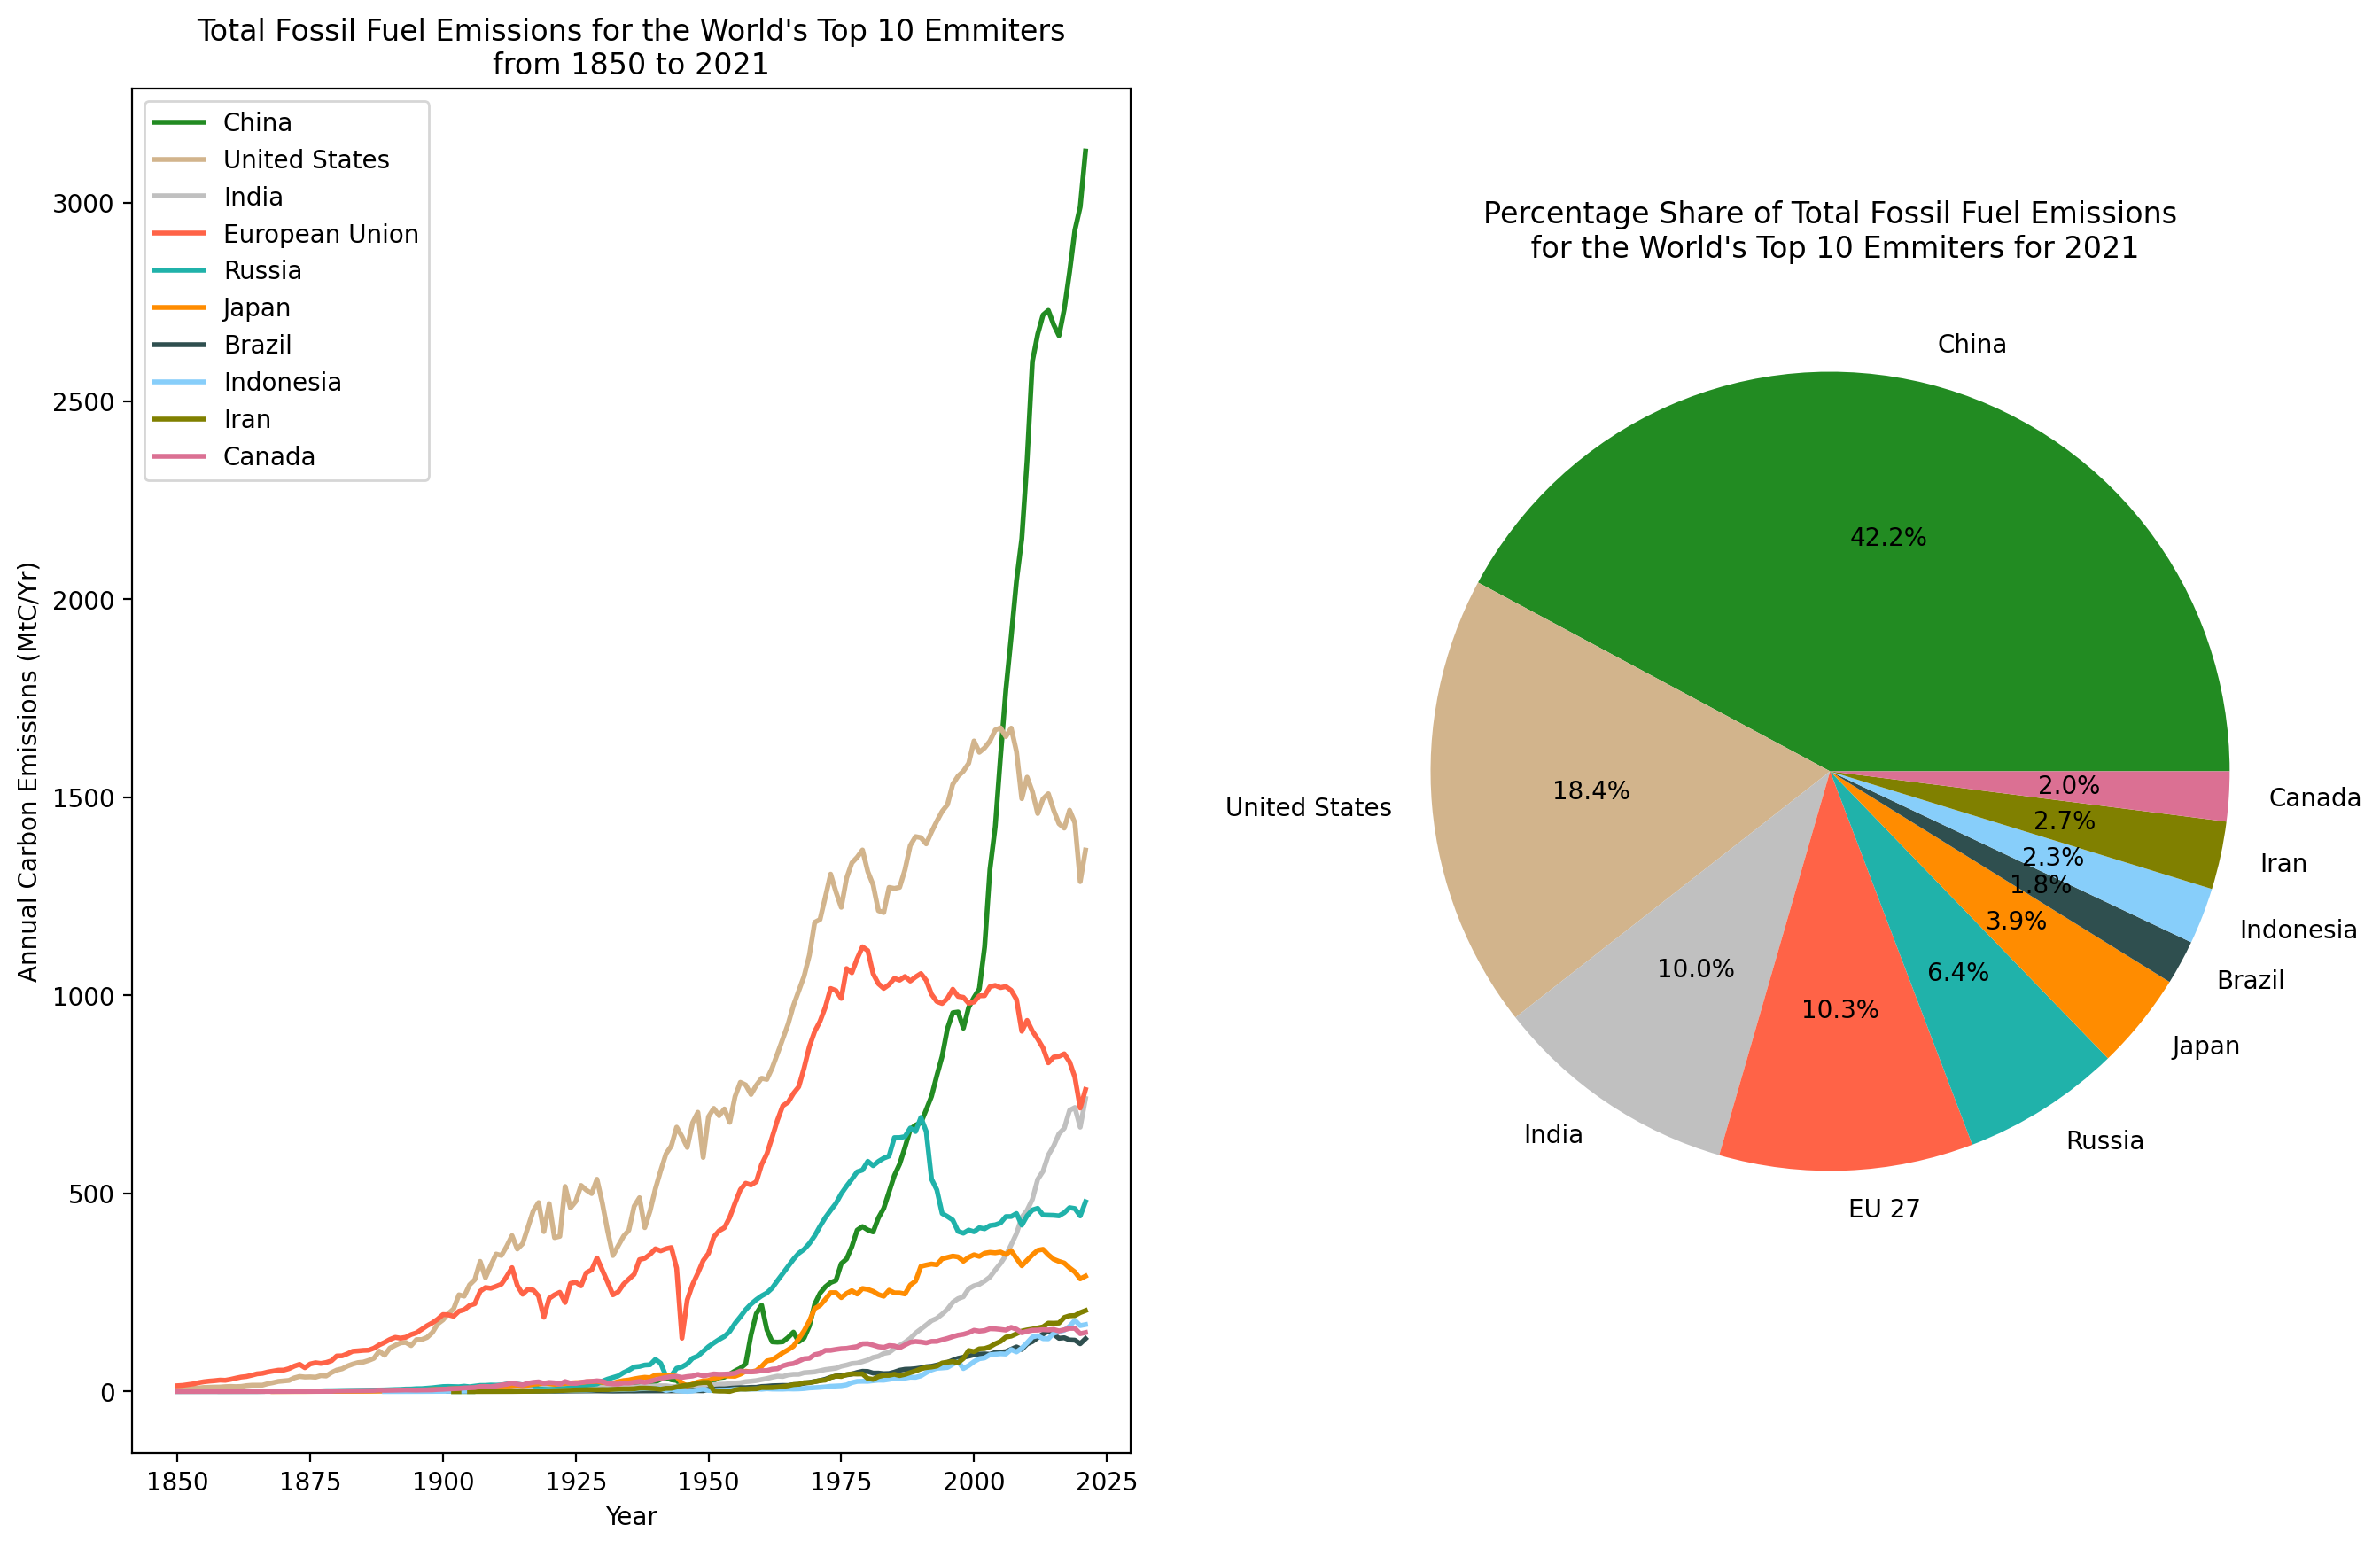

In [16]:
# Figure with two plots
fig, (ax,ax2) = plt.subplots(nrows = 1, ncols =2, figsize = (16, 10))

ax.plot(top_emitters ['Year'],
        top_emitters ['China'],
        linewidth=2,label='China',
        color='forestgreen') 
ax.plot(top_emitters['Year'],
        top_emitters['United States'],
        linewidth=2,label='United States',
        color='tan') 
ax.plot(top_emitters['Year'],
        top_emitters['India'],
        linewidth=2,label='India',
        color='silver') 
ax.plot(top_emitters['Year'],
        top_emitters ['EU 27'],
        linewidth=2,label='European Union',
        color='tomato') 
ax.plot(top_emitters['Year'],
        top_emitters['Russia'],
        linewidth=2,label='Russia',
        color='lightseagreen') 
ax.plot(top_emitters['Year'],
        top_emitters['Japan'],
        linewidth=2,label='Japan',
        color='darkorange') 
ax.plot(top_emitters['Year'],
        top_emitters['Brazil'],
        linewidth=2,label='Brazil',
        color='darkslategrey') 
ax.plot(top_emitters['Year'],
        top_emitters['Indonesia'],
        linewidth=2,label='Indonesia',
        color='lightskyblue') 
ax.plot(top_emitters['Year'],
        top_emitters['Iran'],
        linewidth=2,label='Iran',
        color='olive') 
ax.plot(top_emitters['Year'],
        top_emitters['Canada'],
        linewidth=2,label='Canada',
        color='palevioletred') 

## plot a legend on the ax
ax.legend()

## add plot title:
ax.set_title("Total Fossil Fuel Emissions for the World's Top 10 Emmiters\nfrom 1850 to 2021")

## add axes labes:
ax.set_ylabel('Annual Carbon Emissions (MtC/Yr)')
ax.set_xlabel('Year')

#Add vertical grid 
#ax.grid(True,axis='x',linestyle='--', linewidth=0.5, color = 'dimgray')

#Second plot

# Define custom colors for the pie chart (you can choose any colors)
colors = ['forestgreen', 'tan', 'silver', 'tomato', 'lightseagreen', 'darkorange', 
          'darkslategrey', 'lightskyblue', 'olive', 'palevioletred']

#Create a pie plot of the 10 ghg emissions for the top 10 countries 
ax2.pie(top_emitters_2021['Percentage'], #Column with percentages of the dataframe
            #figsize=(5, 5),#Size of the pie
            #map='BrBG',#Set the colors
            #legend=False, #Add legend
        labels=top_emitters_2021.index,#Add label
        colors=colors,
        autopct='%1.1f%%') #Set the format of the labels: One decimal point and add the % symbol
ax2.set_title("Percentage Share of Total Fossil Fuel Emissions\n for the World's Top 10 Emmiters for 2021")

**Figure 4.** Annual carbon emissions from fossil fuels from 1850 to 2021 (left panel), along with the distribution of total carbon emissions in 2021 among the world's top 10 emitters (right panel) (Global Carbon Project, 2022).

Both the line plot and pie chart visualizations provide valuable insights into global greenhouse gas emissions, but each serves a different purpose. **The line plot** is particularly useful for illustrating temporal trends in emissions, showing how the contributions of the top 10 emitters have evolved from 1850 to 2021. It allows viewers to identify key historical patterns, such as the rapid rise in China's emissions since the early 2000s and the stabilization or decline in emissions from the United States and the European Union. This makes the line plot ideal for analyzing long-term changes and the rate of emissions growth over time.

In contrast, **the pie chart** provides a snapshot of current emissions, highlighting the proportional contributions of each country for the year 2021. With clear percentage labels, the pie chart emphasizes which countries are the largest emitters today, making it a great tool for understanding current responsibilities and global emission shares. While the line plot excels at showing historical shifts, the pie chart effectively communicates the current breakdown of emissions. Together, these visualizations offer both a historical perspective and a current overview of global emissions by country.

### <span style = "color: red">13</span>

#### While the previous visualizations focused on the top emitting countries and their respective contributions to global carbon emissions, it is equally **important to examine the sources of these emissions**. By analyzing annual carbon emissions by emission type, we can gain a deeper understanding of the primary drivers behind global carbon emissions. 

In [23]:
#Annual Carbon emissions by emission type
anual_C_emissions 

,Year,fossil.emissions.excluding.carbonation (MtC/yr),Coal (MtC/yr),Oil (MtC/yr),Gas (MtC/yr),Cement.emission (MtC/yr),Flaring (MtC/yr),Other (MtC/yr),Per.Capita (MtC/yr)
0,1850,53.74,53.74,0.00,0.00,0.00,0.00,0.00,0.04
1,1851,54.26,54.26,0.00,0.00,0.00,0.00,0.00,0.04
2,1852,56.65,56.65,0.00,0.00,0.00,0.00,0.00,0.04
3,1853,59.28,59.28,0.00,0.00,0.00,0.00,0.00,0.05
4,1854,69.63,69.63,0.00,0.00,0.00,0.00,0.00,0.05
...,...,...,...,...,...,...,...,...,...
167,2017,9851.73,3959.33,3341.33,1950.03,411.55,106.98,82.50,1.30
168,2018,10050.90,4024.79,3347.71,2055.09,428.28,112.48,82.55,1.31
169,2019,10120.79,4019.10,3369.45,2087.21,441.46,119.88,83.69,1.30
170,2020,9624.48,3868.60,3054.53,2062.31,446.93,111.24,80.87,1.23


In [17]:
#Select the world's top 10 emitters
activity_emissions = anual_C_emissions [['Year','Coal (MtC/yr)','Oil (MtC/yr)','Gas (MtC/yr)','Cement.emission (MtC/yr)',
                                   'Flaring (MtC/yr)']]
#Change the name of the columns
activity_emissions.columns = ['Year','Coal','Oil','Gas','Cement','Flaring']
activity_emissions

,Year,Coal,Oil,Gas,Cement,Flaring
0,1850,53.74,0.00,0.00,0.00,0.00
1,1851,54.26,0.00,0.00,0.00,0.00
2,1852,56.65,0.00,0.00,0.00,0.00
3,1853,59.28,0.00,0.00,0.00,0.00
4,1854,69.63,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...
167,2017,3959.33,3341.33,1950.03,411.55,106.98
168,2018,4024.79,3347.71,2055.09,428.28,112.48
169,2019,4019.10,3369.45,2087.21,441.46,119.88
170,2020,3868.60,3054.53,2062.31,446.93,111.24


Text(0.5, 0, 'Year')

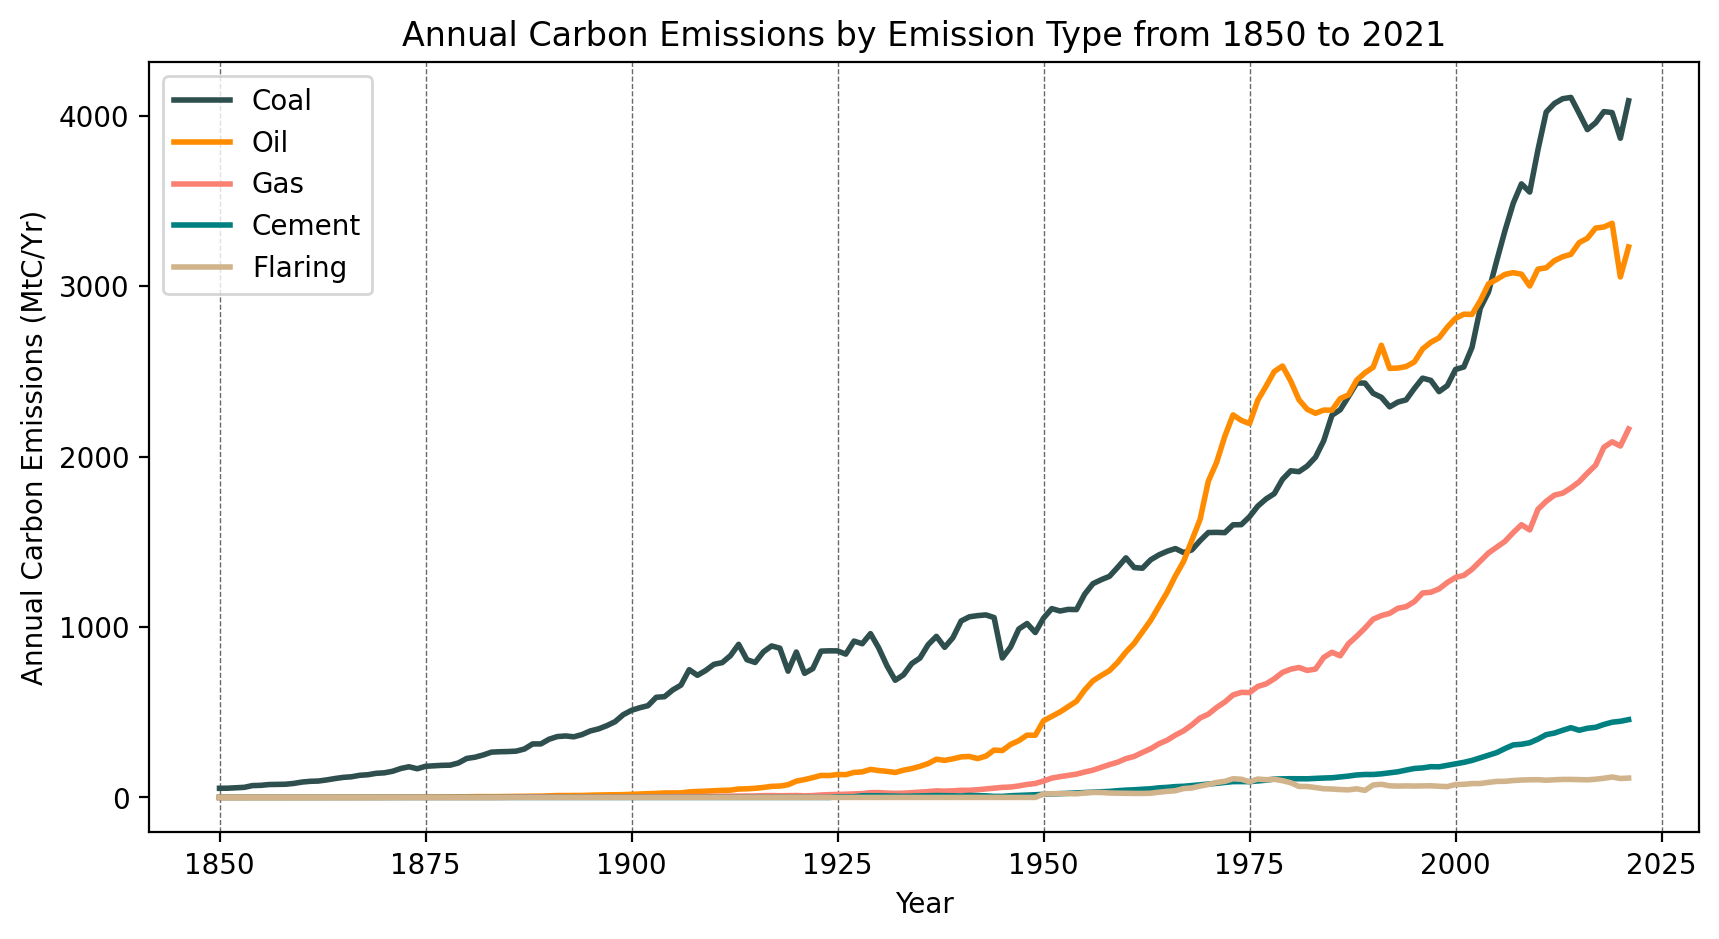

In [18]:
fig, ax = plt.subplots(figsize = (10, 5))

ax.plot(activity_emissions ['Year'],
        activity_emissions ['Coal'],
        linewidth=2,label='Coal',
        color='darkslategrey') 
ax.plot(activity_emissions ['Year'],
        activity_emissions ['Oil'],
        linewidth=2,label='Oil',
        color='darkorange') 
ax.plot(activity_emissions ['Year'],
        activity_emissions ['Gas'],
        linewidth=2,label='Gas',
        color='salmon') 
ax.plot(activity_emissions ['Year'],
        activity_emissions ['Cement'],
        linewidth=2,label='Cement',
        color='teal') 
ax.plot(activity_emissions ['Year'],
        activity_emissions ['Flaring'],
        linewidth=2,label='Flaring',
        color='tan') 


#Add vertical grid 
ax.grid(True,axis='x',linestyle='--', linewidth=0.5, color = 'dimgray')

## plot a legend on the ax
ax.legend()

## add plot title:
ax.set_title("Annual Carbon Emissions by Emission Type from 1850 to 2021")

## add axes labes:
ax.set_ylabel('Annual Carbon Emissions (MtC/Yr)')
ax.set_xlabel('Year')

**Figure 5.** Annual carbon emissions of five major emission sources: Coal, Oil, Gas, Cement, and Flaring from 1850 to 2021 (Global Carbon Project, 2022).

Most of the emissions start  to increase in the lower-half of the 20th century, with the exception of **coal**, which has historically been the **largest contributor**, with emissions rising steadily since the mid-19th century and experiencing a sharp increase after 1950. However, oil emissions saw rapid growth starting in the early 20th century, spiked significantly post-World War II, reflecting the global expansion of oil consumption for transportation, industry, and energy production.  Gas emissions began to rise notably around 1950 and have continued to grow steadily. Flaring, the smallest contributor, has remained relatively stable over time, representing emissions from the burning of excess natural gas during oil extraction. The sharp rise in emissions from coal, oil, and gas highlights their central roles in global energy systems and industrial processes, driving the vast majority of global carbon emissions over the last century (Dhakal et al., 2022). 

### <span style = "color: red">14</span>

### So far, we have focus our visualizations and analysis on the sources and distribution of carbon emissions, however, to further understand the impacts of rising carbon emissions, we can explore global temperature changes. 

Exploring global temperature changes using **reanalysis** datasets like ERA5 (ECMWF) and JRA-55 (Japanese Meteorological Agency), alongside **observational datasets** such as Berkeley Earth Surface Temperatures, NASA GISTEMP, NOAA Global Temp and HadCRUT5, provides a comprehensive understanding of global surface temperature anomalies. Reanalysis datasets offer a consistent, model-driven view of climate dynamics, while observational datasets capture direct measurements, enabling cross-validation of trends. Together, these datasets help us track warming patterns, assess the progression of climate change, and better understand its impacts, such as more frequent extreme weather events, rising sea levels, and shifts in ecosystems.

> ### Climate reanalysis is a systematic approach to produce data sets for climate monitoring and research. This process combines past observations with numerical models to generate consistent time series of multiple climate variables.

Source: https://climatedataguide.ucar.edu/

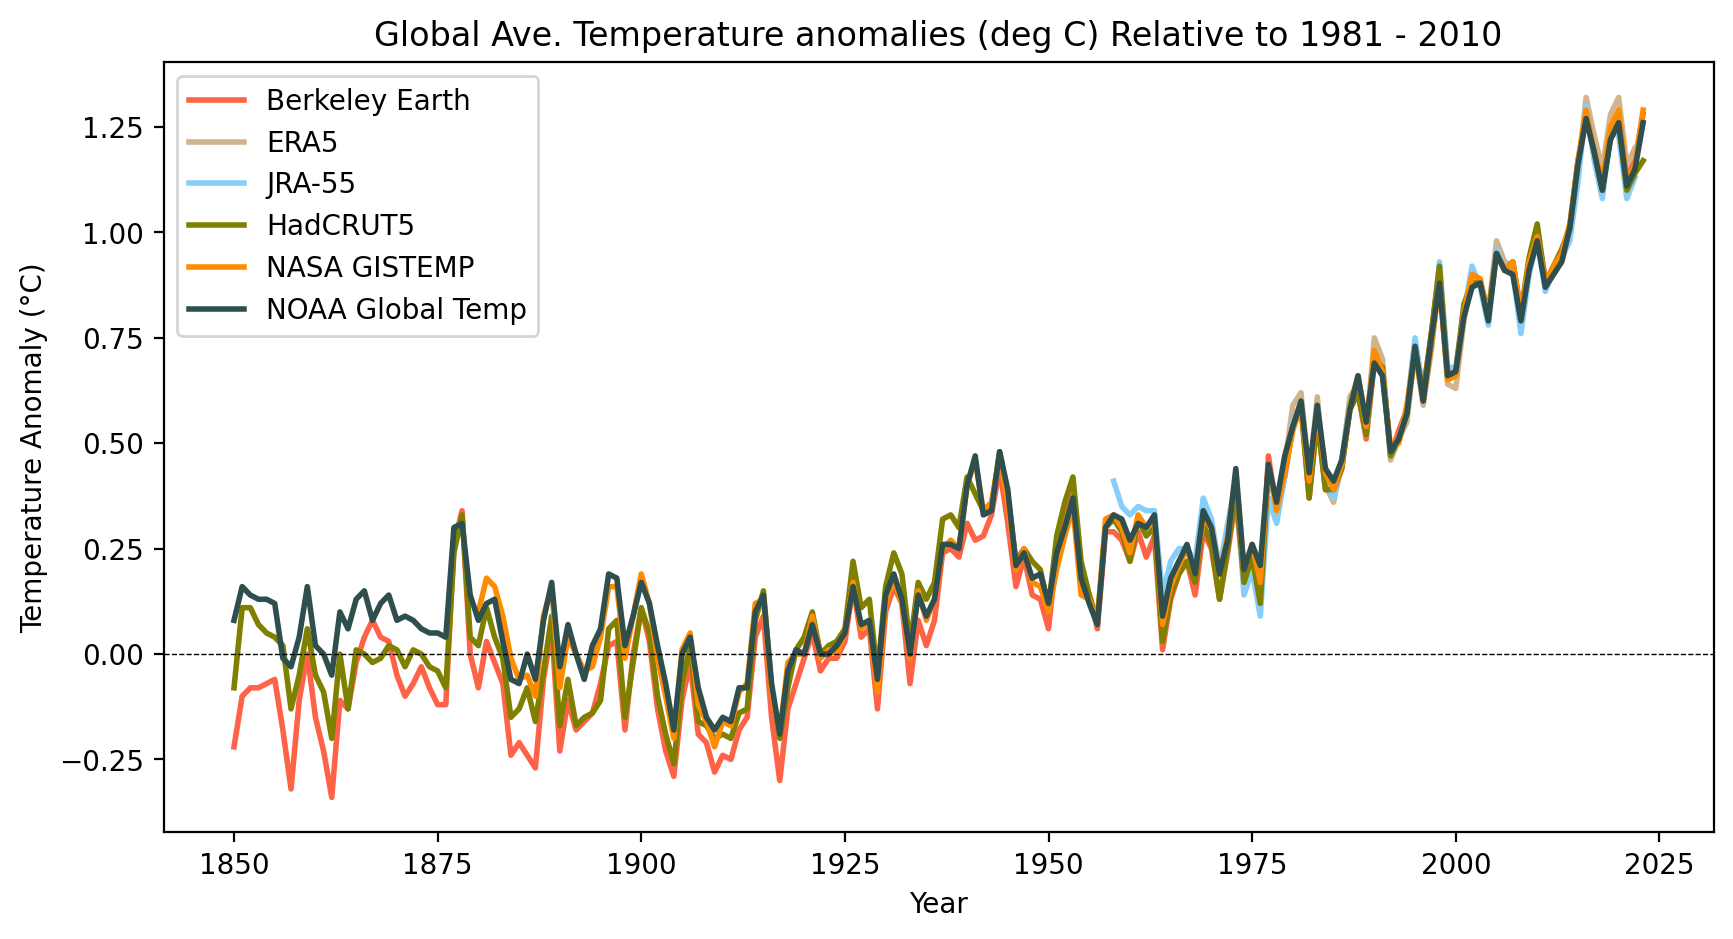

In [23]:
fig, ax = plt.subplots(figsize = (10, 5))

# Plotting global mean surface air temperature datasets
ax.plot(Berkeley_temp['Year'], 
        Berkeley_temp['Berkeley Earth (degC)'], 
        label='Berkeley Earth',
        color='tomato',linewidth=2)

ax.plot(ERA5_temp['Year'],
        ERA5_temp['ERA5 (degC)'], 
        label='ERA5', 
        color='tan', linewidth=2)

ax.plot(JRA_temp['Year'],
        JRA_temp['JRA-55 (degC)'],
        label='JRA-55',
        color='lightskyblue', linewidth=2)

ax.plot(HadCRUT5_temp['Year'], 
        HadCRUT5_temp['HadCRUT5 (degC)'], 
        label='HadCRUT5', 
        color='olive', linewidth=2)

ax.plot(GISTEMP['Year'], 
        GISTEMP['GISTEMP (degC)'], 
        label='NASA GISTEMP', 
        color='darkorange', linewidth=2)

ax.plot(NOAA_temp['Year'],
            NOAA_temp['NOAAGlobalTemp (degC)'],
        label='NOAA Global Temp', 
        color='darkslategrey', linewidth=2)

# plot a legend on the ax
ax.legend()

## add plot title:
ax.set_title("Global Ave. Temperature anomalies (deg C) Relative to 1981 - 2010")

## add axes labes:
ax.set_ylabel('Temperature Anomaly (°C)')
ax.set_xlabel('Year')

## add a horizontal line at 0 !
ax.axhline(0,color='k',linestyle='--', linewidth=0.5)

#Add vertical grid 
#ax.grid(True,axis='x',linestyle='--', linewidth=0.5, color = 'dimgray')

**Figure 6.** Global average air temperature anomalies for different datasets from 1850 to 2023

In [41]:
#Minimum temperature anomaly between 1850 and 2023
print('Minimum temperature anomaly (1850-2023):', Berkeley_temp['Berkeley Earth (degC)'].min(), '°C')
#Maximum temperature anomaly between 1850 and 1925
print('Maximum temperature anomaly (1850-1925):',GISTEMP.loc[(GISTEMP['Year'] <= 1925)]['GISTEMP (degC)'].max(), #Filter the dataframe with Year below 1925 and calculate the maximum for the column with the temperature value
      '°C')
#Maximum temperature anomaly between 1850 and 2023
print('Maximum temperature anomaly (1850-2023):',GISTEMP['GISTEMP (degC)'].max(),'°C')

Minimum temperature anomaly (1850-2023): -0.34 °C
Maximum temperature anomaly (1850-1925): 0.19 °C
Maximum temperature anomaly (1850-2023): 1.29 °C


### Although the datasets cover different time periods, they all show an overall upward trend in surface air temperature anomalies. Between 1850 and 1925, the anomalies oscillated around zero, ranging from as low as -0.34°C to as high as 0.19°C. However, since the mid-20th century, the temperature anomalies have been consistently positive and steadily increasing. By 2023, the temperature anomaly reached 1.29°C, highlighting the ongoing trend of global warming.

### <span style = "color: red">16 & 18</span>

### So far, we have observed the global air surface temperature anomalies, but it's important to distinguish between what is happening over land and over the ocean.

Text(0.5, 0, 'Year')

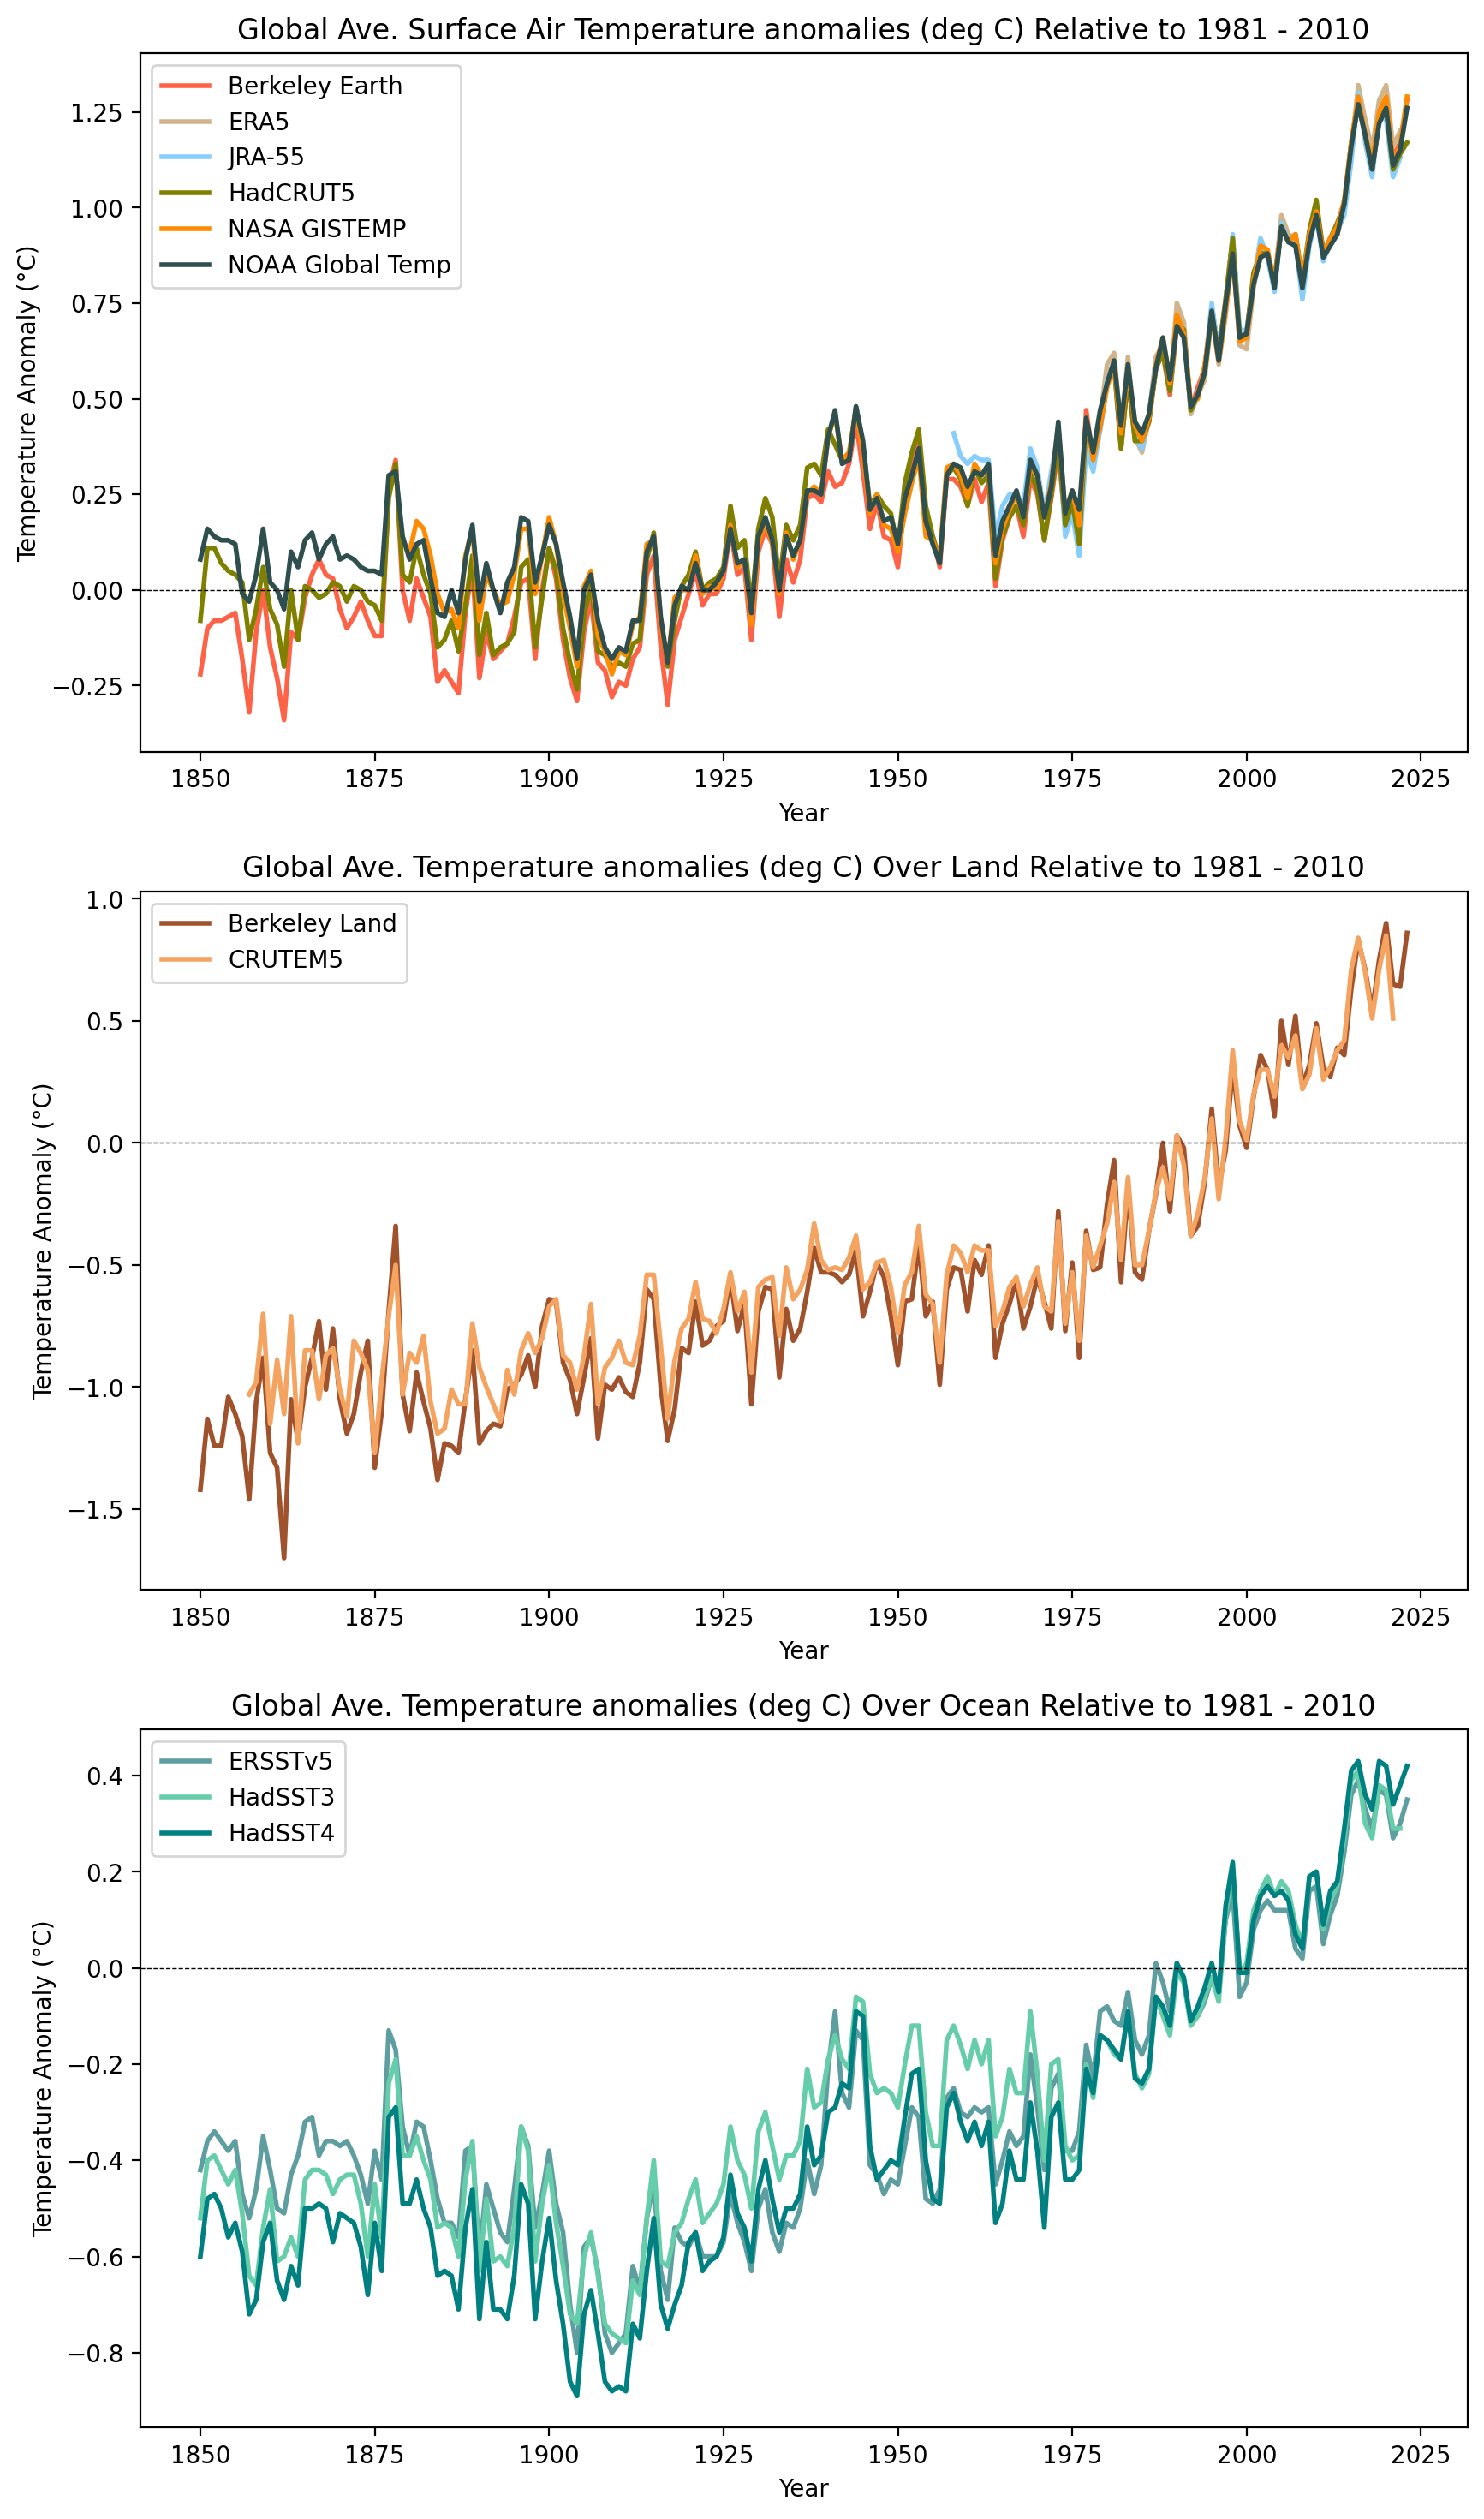

In [43]:
# Figure with two plots
fig, (ax,ax2,ax3) = plt.subplots(nrows = 3, ncols = 1, figsize = (10, 18))

#Global mean surface temperature anomalies

ax.plot(Berkeley_temp['Year'], 
        Berkeley_temp['Berkeley Earth (degC)'], 
        label='Berkeley Earth',
        color='tomato',linewidth=2)

ax.plot(ERA5_temp['Year'],
        ERA5_temp['ERA5 (degC)'], 
        label='ERA5', 
        color='tan', linewidth=2)

ax.plot(JRA_temp['Year'],
        JRA_temp['JRA-55 (degC)'],
        label='JRA-55',
        color='lightskyblue', linewidth=2)

ax.plot(HadCRUT5_temp['Year'], 
        HadCRUT5_temp['HadCRUT5 (degC)'], 
        label='HadCRUT5', 
        color='olive', linewidth=2)

ax.plot(GISTEMP['Year'], 
        GISTEMP['GISTEMP (degC)'], 
        label='NASA GISTEMP', 
        color='darkorange', linewidth=2)

ax.plot(NOAA_temp['Year'],
            NOAA_temp['NOAAGlobalTemp (degC)'],
        label='NOAA Global Temp', 
        color='darkslategrey', linewidth=2)

# plot a legend on the ax
ax.legend()

## add plot title:
ax.set_title("Global Ave. Surface Air Temperature anomalies (deg C) Relative to 1981 - 2010")

## add axes labes:
ax.set_ylabel('Temperature Anomaly (°C)')
ax.set_xlabel('Year')

## add a horizontal line at 0 !
ax.axhline(0,color='k',linestyle='--', linewidth=0.5)

# Plotting land surface air temperature datasets

ax2.plot(Berkeley_lsat['Year'], 
        Berkeley_lsat['Berkeley Earth Land (degC)'],
        label='Berkeley Land', 
        color='sienna', linewidth=2)

ax2.plot(CRUTEM5_lsat['Year'],
        CRUTEM5_lsat['CRUTEM5 (degC)'], 
        label='CRUTEM5', 
        color='sandybrown', linewidth=2)

# plot a legend on the ax
ax2.legend()

## add plot title:
ax2.set_title("Global Ave. Temperature anomalies (deg C) Over Land Relative to 1981 - 2010")

## add axes labes:
ax2.set_ylabel('Temperature Anomaly (°C)')
ax2.set_xlabel('Year')

## add a horizontal line at 0 !
ax2.axhline(0,color='k',linestyle='--', linewidth=0.5)

# Plotting sea surface temperature datasets
ax3.plot(ERSST_sst['Year'], 
        ERSST_sst['ERSSTv5 (degC)'],
        label='ERSSTv5', 
        color='cadetblue', linewidth=2)

ax3.plot(hadsst3_sst['Year'],
        hadsst3_sst['HadSST3 (degC)'], 
        label='HadSST3', 
        color='mediumaquamarine', linewidth=2)

ax3.plot(hadsst4_sst['Year'],
        hadsst4_sst['HadSST4 (degC)'], 
        label='HadSST4', 
        color='teal', linewidth=2)

# plot a legend on the ax
ax3.legend()

## add a horizontal line at 0 !
ax3.axhline(0,color='k',linestyle='--', linewidth=0.5)

## add plot title:
ax3.set_title("Global Ave. Temperature anomalies (deg C) Over Ocean Relative to 1981 - 2010")

## add axes labes:
ax3.set_ylabel('Temperature Anomaly (°C)')
ax3.set_xlabel('Year')

#Save image in working directory
#fig.savefig('Temp_Anomalies.png')

**Figure 7.** Global average surface air temperature anomalies (top), surface air temperature anomalies over land (middle), and surface air temperature anomalies over ocean (bottom), for different datasets from 1850 to 2023. 

The two plots illustrate the global average temperature anomalies over land and ocean, relative to the 1981-2010 baseline, using multiple datasets. The first plot, comparing the Berkeley Earth and CRUTEM5 datasets, shows a consistent warming trend over land since the mid-19th century, with a sharp acceleration in temperatures after the 1970s, reaching nearly 1°C above the baseline by 2020. The second plot, comparing the ERSSTv5, HadSST3, and HadSST4 datasets, reveals a similar warming trend over the oceans, though with a lower magnitude, approaching 0.4°C above the baseline by 2020. Both plots demonstrate clear and significant warming since the mid-20th century, with **land warming more rapidly than oceans**. The alignment across multiple datasets in both plots further reinforces the reliability of these observed trends.

Generally, land areas are warming at a faster rate than the oceans due to their lower **heat capacity**, meaning they respond more quickly to changes in energy. In contrast, oceans absorb and store heat more efficiently, leading to a slower but steady increase in temperature. This difference is crucial, as it impacts weather patterns, sea levels, and ecosystems. Over land, the accelerated warming contributes to more extreme heat events, while over the oceans, the slower warming drives changes in marine environments and an increase in sea surface temperatures (Byrne, 2020).


### <span style = "color: red">15</span>

### The NOAA Merged Land Ocean Global Surface Temperature Analysis (NOAA Global Temp) combines long-term sea surface (water) temperature (SST) and land surface (air) temperature datasets to create a complete, accurate depiction of global temperature trends. 
Source: https://www.ncei.noaa.gov/products/land-based-station/noaa-global-temp

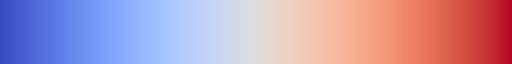

In [44]:
# Import cm and colormaps from matplotlib and create aliases
from matplotlib import cm
from matplotlib import colormaps as colormap
cool_warm_cmap = colormap["coolwarm"]
cool_warm_cmap

In [18]:
NOAA_temp

,Year,NOAAGlobalTemp (degC),NOAAGlobalTemp uncertainty
0,1850,0.08,0.152
1,1851,0.16,0.149
2,1852,0.14,0.148
3,1853,0.13,0.150
4,1854,0.13,0.150
...,...,...,...
169,2019,1.22,NaN
170,2020,1.26,NaN
171,2021,1.11,NaN
172,2022,1.15,NaN


In [45]:
# Normalize data for colormap
NOAA_temp_values = NOAA_temp['NOAAGlobalTemp (degC)']  ### Set the values to be used in our colormap
norm = plt.Normalize(min(NOAA_temp_values), 
                     max(NOAA_temp_values))

# Apply colormap --- two different colormaps as examples
cmap_coolwarm = colormap.get_cmap('coolwarm')
cmap_thermal = colormap.get_cmap(cmocean.cm.thermal)

bar_colors_coolwarm = cmap_coolwarm(norm(NOAA_temp_values))
bar_colors_thermal = cmap_thermal(norm(NOAA_temp_values))

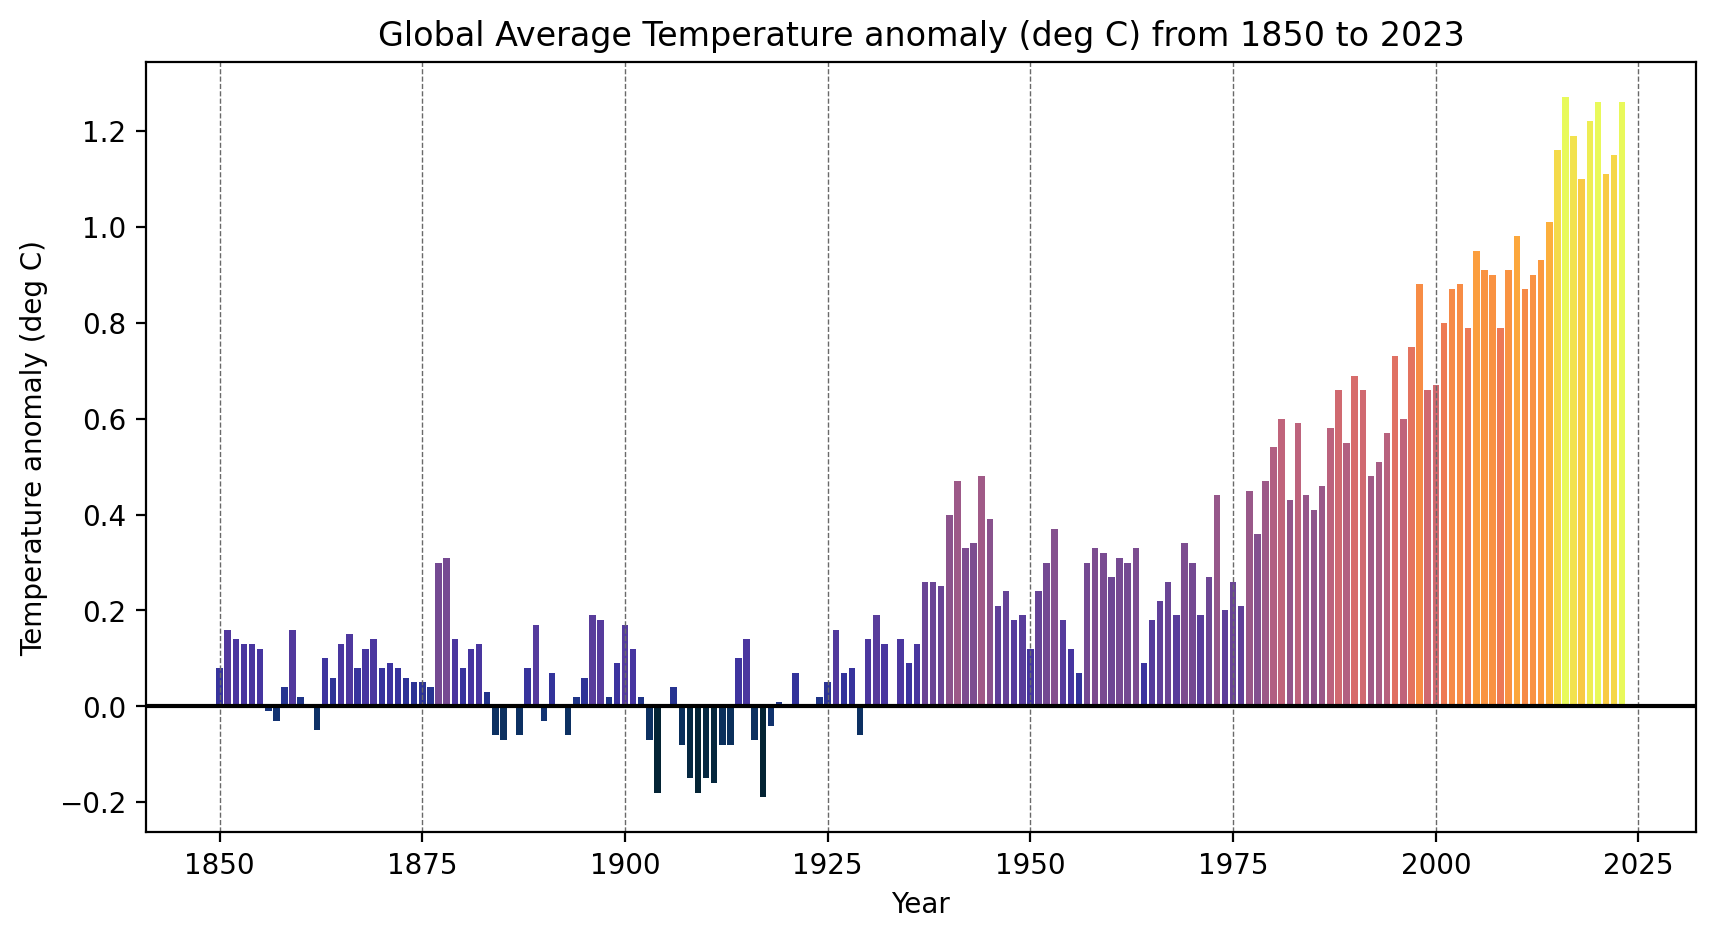

In [46]:
fig, ax = plt.subplots(figsize = (10, 5))

ax.bar(NOAA_temp['Year'],
       NOAA_temp['NOAAGlobalTemp (degC)'],
       linewidth=2,
       label='Berkeley Earth global mean surface air temp anomaly',
       color=bar_colors_thermal) 

## add a horizontal line at 0 !
ax.axhline(0,color='k')

## add plot title:
ax.set_title('Global Average Temperature anomaly (deg C) from 1850 to 2023')

## add axes labes:
ax.set_ylabel('Temperature anomaly (deg C)')
ax.set_xlabel('Year')

ax.grid(True,axis='x',linestyle='--', linewidth=0.5, color = 'dimgray') ### add dashed grid lines

**Figure 8.** Global average air temperature anomaly from the NOAA Merged Land Ocean Global Surface Temperature Analysis (NOAA Global Temp) from 1850 to 2023

During the late 19th and early 20th centuries, temperature anomalies fluctuated around 0°C, indicating minimal overall warming. However, starting around the mid-20th century, there is a pronounced upward trend in global temperatures. This warming accelerates after the 1970s, with anomalies consistently rising above 0.5°C. By 2023, the anomaly reaches approximately 1.2°C above the baseline. The chart's color gradient, shifting from cooler blues to warmer yellows, visually represents the progression of global warming, reflecting the increasing impact of anthropogenic climate change.

### <span style = "color: red">17</span>

In [32]:
#Calculate the average temperature anomaly during the baseline period from 1891 to 2010
baseline = NOAA_temp.loc[(NOAA_temp['Year'] >= 1981)& (NOAA_temp['Year'] <= 2010)]['NOAAGlobalTemp (degC)'].mean()
print('Baseline 1981-2010:',round(baseline,3),'°C')

Baseline 1981-2010: 0.69 °C


In [33]:
#Calculate how much the global temperature has risen in 2022
temp_2022 = NOAA_temp[NOAA_temp['Year'] == 2022]
NOAA_temp_rise = temp_2022['NOAAGlobalTemp (degC)'].values[0] - baseline

print('Ave. temperatures have risen',round(NOAA_temp_rise,2),'°C')

Ave. temperatures have risen 0.46 °C


Based on the analysis of the global surface temperature analysis (NOAA Global Temp) dataset, the global average temperature during the **baseline period from 1981 to 2010** was already **0.69°C warmer** than the pre-industrial baseline. In recent years, **temperatures have risen an additional 0.46°C** relative to this baseline. This continued increase in global temperatures highlights the acceleration of climate change, particularly in recent decades. 

> The current warming, now at approximately 1.15°C, underscores the urgency of mitigating further increases, as the world approaches the 1.5°C threshold established by **The Paris Agreement**, beyond which the risks and impacts of climate change are expected to become increasingly severe.
> 
> Source: https://unfccc.int/process-and-meetings/the-paris-agreement

### <span style = "color: red">Conclusions</span>

* Greenhouse gases (GHGs) play a critical role in maintaining Earth's steady-state climate by regulating the flow of energy through the atmosphere. The balance between incoming shortwave radiation from the Sun and outgoing longwave radiation from the Earth's surface is influenced by the presence of GHGs, which absorb and re-emit infrared radiation, warming the planet. 

* The composition of the atmosphere is primarily made up of nitrogen (78%), oxygen (21%), and trace amounts of other gases, including GHGs like carbon dioxide (CO₂), methane (CH₄), nitrous oxide (N₂O), and water vapor. Among these, GHGs have the unique ability to absorb and emit longwave radiation, unlike nitrogen (N₂), which does not interact with infrared radiation due to its molecular structure.

* Human activities, particularly since the Industrial Revolution, have led to a significant increase in GHG concentrations, amplifying the natural greenhouse effect, now referred to as the enhanced greenhouse effect. This has resulted in higher global temperatures, with CO₂ levels reflecting a 48% increase. Methane has increased even more dramatically (170%) due to activities like agriculture and fossil fuel production.

* The analysis of GHG by country and economic sector highlights the significant disparities in emissions contributions across nations, with a small number of top emitters driving the majority of global emissions. The world's largest GHG emitters (China, the United States, and India) account for 42.6% of total global emissions.

* Across these top-emitting nations, electricity and heat production emerges as the dominant source of emissions. This reflects the heavy reliance on fossil fuels for energy generation, which continues to drive a substantial portion of their emissions.

* The analysis of global temperature datasets reveals a clear and consistent warming trend over the past century, particularly since the mid-20th century. Despite differences in the time spans and sources of these datasets, the overall pattern remains the same: global temperatures are rising.

* Due to its lower heat capacity, there is a differential warming between land and ocean, where land is warming faster than the oceans. While the oceans absorb and store more heat, they do so more slowly, contributing to gradual warming. This difference has significant implications, including more extreme heat events over land and shifts in marine ecosystems due to rising sea surface temperatures.

### References

Alan Buis (2019). The Atmosphere: Getting a Handle on Carbon Dioxide. https://science.nasa.gov/earth/climate-change/greenhouse-gases/the-atmosphere-getting-a-handle-on-carbon-dioxide/

Dhakal, S., Minx, J. C., Toth, F. L., Abdel-Aziz, A., Meza, M. J. F., Hubacek, K., Jonckheere, I. G. C., Kim, Y.-G., Nemet, G. F., Pachauri, S., Tan, X. C., & T., W. (2022). Emissions Trends and Drivers. In Climate Change 2022 - Mitigation of Climate Change. Cambridge University Press. https://doi.org/10.1017/9781009157926.004

EPA (2024). Basics of Climate Change. https://www.epa.gov/climatechange-science/basics-climate-change#:~:text=The%20greenhouse%20effect%20helps%20trap,the%20earth%20to%20warm%20up.

EPA (2024b). Understanding Global Warming Potentials. https://www.epa.gov/ghgemissions/understanding-global-warming-potentials

Friedrich, J., Ge, M., Pickens, A., & Vigna, L. (2023). This Interactive Chart Shows Changes in the World's Top 10 Emitters. World Resources Institute. https://www.wri.org/insights/interactive-chart-shows-changes-worlds-top-10-emitters

Global Carbon Project (2022). Supplemental data of Global Carbon Budget 2022 (Version 1.0) [Data set]. Global Carbon Project. https://doi.org/10.18160/gcp-2022

IPCC. (2021). Annex VII: Glossary. In Climate Change 2021 – The Physical Science Basis.. Contribution of Working Group I to the Sixth Assessment Report of the Intergovernmental Panel on Climate Change. Cambridge University Press. https://doi.org/10.1017/9781009157896.022

Keeling, C.D., & Whorf, T.P. (2004). Atmospheric Carbon Dioxide Concentrations at 10 Locations Spanning Latitudes 82°N to 90°S.

Michael Byrne (2020). Guest post: Why does land warm up faster than the oceans? Carbon Brief. https://www.carbonbrief.org/guest-post-why-does-land-warm-up-faster-than-the-oceans/

Pierrehumbert, R. T. (2011). Infrared radiation and planetary temperature. Physics Today. https://geosci.uchicago.edu/~rtp1/papers/PhysTodayRT2011.pdf

Rebecca Lindsey (2024). Climate Change: Atmospheric Carbon Dioxide. https://www.climate.gov/news-features/understanding-climate/climate-change-atmospheric-carbon-dioxide

Saunois, M., Bousquet, P., Poulter, B., Peregon, A., Ciais, P., Canadell, J. G., Dlugokencky, E. J., Etiope, G., Bastviken, D., Houweling, S., Janssens-Maenhout, G., Tubiello, F. N., Castaldi, S., Jackson, R. B., Alexe, M., Arora, V. K., Beerling, D. J., Bergamaschi, P., Blake, D. R., Brailsford, G., Bruhwiler, L., Crevoisier, C., Crill, P., Covey, K., Frankenberg, C., Gedney, N., Höglund-Isaksson, L., Ishizawa, M., Ito, A., Joos, F., Kim, H.-S., Kleinen, T., Krummel, P., Lamarque, J.-F., Langenfelds, R., Locatelli, R., Machida, T., Maksyutov, S., Melton, J. R., Morino, I., Naik, V., O'Doherty, S., Parmentier, F.-J. W., Patra, P. K., Peng, C., Peng, S., Peters, G. P., Pison, I., Prinn, R., Ramonet, M., Riley, W. J., Saito, M., Santini, M., Schroeder, R., Simpson, I. J., Spahni, R., Takizawa, A., Thornton, B. F., Tian, H., Tohjima, Y., Viovy, N., Voulgarakis, A., Weiss, R., Wilton, D. J., Wiltshire, A., Worthy, D., Wunch, D., Xu, X., Yoshida, Y., Zhang, B., Zhang, Z., and Zhu, Q.: Variability and quasi-decadal changes in the methane budget over the period 2000–2012, Atmos. Chem. Phys., 17, 11135–11161, https://doi.org/10.5194/acp-17-11135-2017, 2017.

Sustainable Gas Institute (2023). Methane origins – part II: The millennium methane plateau and post-plateau rise. Imperial. https://blogs.imperial.ac.uk/sustainable-gas-institute/2023/05/04/methane-origins-part-ii-the-millennium-methane-plateau-and-post-plateau-rise-2/

Tans, P., & Thoning, K. (2020). How we measure background CO2 levels on Mauna Loa. NOAA Global Monitoring Laboratory. https://gml.noaa.gov/ccgg/about/co2_measurements.html

UNEP, & CCAC. (2021). Global methane assessment: Benefits and costs of mitigating methane emissions. https://www.unep.org/resources/report/global-methane-assessment-benefits-and-costs-mitigating-methane-emissions